# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:
- сделать запрос данных подлючения и поместить в `.env` 

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Используйте ячейки типа Code для вашего кода,
# а ячейки типа Markdown для комментариев и выводов

In [2]:
# При необходимости добавляйте новые ячейки для кода или текста

С помощью Python подлючимся к базе данных. Для этого импортируем библиотеки `SQLAlchemy` и `psycopg2`. Если их еще нет, то установим через `pip`. Вместо `psycopg2` установим `psycopg2-binary`во избежание возможной ошибки.

Также импортируем `pandas` и `pyplot` из `matplotlib`, отдельно функцию `create_engine()` из `SQLAlchemy`, а также `phik_matrix` из `phik` и `seaborn`. Импортируем `load_dotenv` из `dotenv` и `os` для работы с `.env`:

In [3]:
# Импорты
import os

try:
    from dotenv import load_dotenv
except ImportError:
    !pip install python-dotenv
    from dotenv import load_dotenv

try:
    from sqlalchemy import create_engine
except ImportError:
    print('Устанавливаю и импортирую библиотеку SQLAlchemy и функцию create_engine()')
    !pip install sqlalchemy
    from sqlalchemy import create_engine

try:
    import psycopg2
except ImportError:
    print('Устанавливаю и импортирую библиотеку psycopg2-binary')
    !pip install psycopg2-binary
    import psycopg2
    
try:
    import pandas as pd
except ImportError:
    print('Устанавливаю и импортирую библиотеку pandas')
    !pip install pandas
    import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError:
    print('Устанавливаю и импортирую matplotlib.pyplot')
    !pip install matplotlib
    import matplotlib.pyplot as plt

try:
    from phik import phik_matrix
except ImportError:
    print('Устанавливаю и импортирую библиотеку phik и функцию phik_matrix')
    !pip install phik
    from phik import phik_matrix

try:
    import seaborn as sns
except ImportError:
    print('Устанавливаю и импортирую seaborn')
    !pip install seaborn
    import seaborn as sns

Запишем данные для подлючения к БД в объект `db_config` через `.env`:

In [4]:
load_dotenv()

db_config = {
    'user': os.getenv('DB_USER'),
    'pwd': os.getenv('DB_PASSWORD'),
    'host': os.getenv('DB_HOST'),
    'port': os.getenv('DB_PORT'),
    'db': os.getenv('DB_NAME')
}

С помощью метода `.format()` сформируем строку для подключения:

In [5]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

Создадим соединение, передав строку с данными для подключения в функцию `create_engine()`:

In [6]:
engine = create_engine(connection_string)

Запишем запрос в переменную `query`:

In [7]:
query = '''
SELECT
  p.user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk AS order_dt,
  p.created_ts_msk AS order_ts,
  p.currency_code,
  p.revenue,
  p.tickets_count,
  EXTRACT(DAY FROM created_dt_msk - LAG(created_dt_msk) OVER (
    PARTITION BY user_id 
    ORDER BY created_dt_msk
  )) AS days_since_prev,
  p.event_id,
  e.event_name_code AS event_name,
  e.event_type_main,
  p.service_name,
  r.region_name,
  c.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e USING (event_id)
JOIN afisha.city c USING (city_id)
JOIN afisha.regions r USING (region_id)
WHERE
  device_type_canonical IN ('desktop', 'mobile')
  AND e.event_type_main != 'фильм'
ORDER BY user_id
;
'''

Запишем результат выдачи SQL-запроса в датафрейм `df` с помощью метода `pd.read_sql_query()`:

In [8]:
df = pd.read_sql_query(query, con=engine)

Датафрейм получен. Сформулируем цель проекта, чтобы не забыть её, а после посмотрим на сами данные в датайрейме.

**Цель проекта** - с помощью исследовательского анализа данных понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно (это необходимо для помощи команде маркетинга лучше понимать поведение пользователей).

На снове результатов команда маркетинга сможет:
- быстро выявлять перспективных клиентов и предлагать им персонализированные условия;
- точно настраивать рекламу на аудитории с высокой вероятностью возврата;
- оптимизировать маркетинговые бюджеты;
- повысить общий уровень удержания клиентов.

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

Изучим общую информацию о датафрейме:

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Выведем первые 5 строк датафрейма:

In [10]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


Выведем последние 5 строк:

In [11]:
df.tail()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка
290610,ffff00725179321,mobile,813654,2024-09-25,2024-09-25 15:12:40,rub,802.25,2,NaN,284965,58574140-962c-49a3-af70-b773a05661a3,концерты,Мой билет,Малиновоярский округ,Верховино


Датафрейм `df` содержит 15 столбцов и 290 611 строк, в которых представлена информация о пользователях, заказах билетов, мероприятиях и характеристиках покупок. Данные включают идентификаторы пользователей и заказов, даты покупок, сумму выручки, количество купленных билетов, информацию о мероприятиях, билетных операторах и географии проведения событий.

Названия столбцов соответствуют поставленной задаче и позволяют проводить дальнейший анализ. В большинстве столбцов пропуски отсутствуют. Единственный столбец с пропущенными значениями - `days_since_prev`, где заполнено 268 678 строк из 290 611. Наличие пропусков в данном столбце ожидаемо, поскольку для пользователей с единственной покупкой невозможно рассчитать количество дней с предыдущего заказа.

Типы данных и их корректность:

**Дата и время (`datetime64[ns]`).** Два столбца имеют тип данных `datetime64[ns]`:
- `order_dt` содержит дату оформления заказа;
- `order_ts` содержит дату и точное время оформления заказа.

Для обоих столбцов выбранный тип данных является корректным и не требует изменений.

**Числовые значения с плавающей запятой (`float64`).** Два столбца имеют тип данных `float64`:
- `revenue` хранит сумму выручки по заказу. Использование вещественного типа данных оправдано, поскольку стоимость заказа может содержать дробную часть;
- `days_since_prev` содержит количество дней между текущей и предыдущей покупкой пользователя. Несмотря на то что фактически значения представлены целыми днями, наличие пропусков привело к автоматическому выбору типа `float64`. При необходимости столбец можно преобразовать в целочисленный тип с поддержкой пропусков (`int64`).

**Целочисленные данные (`int64`).** Три столбца имеют тип данных `int64`:
- `order_id` - уникальный идентификатор заказа;
- `tickets_count` - количество приобретённых билетов;
- `event_id` - уникальный идентификатор мероприятия.

Для столбца `tickets_count` тип данных выбран корректно. Столбцы `order_id` и `event_id` содержат идентификаторы, а не числовые показатели, поэтому их можно рассматривать как категориальные признаки. Однако изменение типа данных не является обязательным и зависит от дальнейших задач анализа.

**Строковые данные (`object`).** Восемь столбцов имеют тип данных `object`:
- `user_id` и `event_name` содержат текстовую информацию или идентификаторы в строковом формате, поэтому тип данных выбран корректно;
- `device_type_canonical` содержит всего две категории устройств (desktop и mobile), поэтому данный столбец целесообразно перевести в тип `category`;
- для `currency_code` также отмечается только две валюты (rub и kzt), поэтому этот столбец тоже целесообразно перевести в тип `category`;
- `event_type_main` также представляет ограниченный набор категорий мероприятий, поэтому для него также подойдет тип `category`;
- `service_name`, `region_name` и `city_name`, скорее всего, содержат большее количество уникальных значений, но гораздо меньше, чем количество строк в данных, поэтому их тоже можно перевести в тип `category`.

Таким образом, большинство столбцов уже имеют корректные типы данных. Оптимизацию можно выполнить главным образом за счёт перевода категориальных признаков в тип `category`, а также уменьшением разрядности числовых типов, что позволит уменьшить объём занимаемой памяти.

Скорее всего, дополнительная предобработка будет связана преимущественно с оптимизацией категориальных признаков, проверкой дубликатов и контролем корректности числовых показателей.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


Выгружаем датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год:

In [12]:
df_tenge_rate_2024 = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

Выведем информацию о датафрейме:

In [13]:
df_tenge_rate_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Посомтрим на первые 5 строк:

In [14]:
df_tenge_rate_2024.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Посмотрим на последние 5 строк:

In [15]:
df_tenge_rate_2024.tail()

,data,nominal,curs,cdx
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt
356,2024-12-31,100,19.4860,kzt


Датафрейм состоит из 357 строчек и 4 столбцов. Дата начинается с 10-го января. Пропусков нет ни в одном столбце.

Отметим, что все столбцы, кроме `data` имеют корректный тип значений. Для сравнения и  дальнейших рачетов и преобразований этот тип нужно привести к типу `datetime64[ns]`, как в датафрейме `ds`:

In [16]:
df_tenge_rate_2024[['data']] = df_tenge_rate_2024[['data']].astype('datetime64[ns]')

Проверяем тип и вид:

In [17]:
df_tenge_rate_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 11.3+ KB


In [18]:
df_tenge_rate_2024.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Теперь переведем значения выручки из тенге в рубли, используя значения из нового датафрейма. Для этого воспользуемся удобством  метотда `merge()`. Но сначала переименуем столбец `data` в `order_dt` в датафрейме `df_tenge_rate_2024`:

In [19]:
df_tenge_rate_2024 = df_tenge_rate_2024.rename(columns={'data': 'order_dt'})

Добавим к основному датафрейму `df` курс тенге к рублю через `merge` по `order_dt`:

In [20]:
df = df.merge(
    df_tenge_rate_2024[['order_dt', 'curs']],
    on='order_dt',
    how='left'
)

Создадим новй столбец `revenue_rub`, в который пока поместим выручку в рублях:

In [21]:
df['revenue_rub'] = df['revenue']

Найдем заказы в тенге и пересчитаем для них выручку в рублях:

In [22]:
df.loc[df['currency_code'] == 'kzt', 'revenue_rub'] = (
    df.loc[df['currency_code'] == 'kzt', 'revenue']
    * df.loc[df['currency_code'] == 'kzt', 'curs']
    / 100
)

Удалим временный столбец с курсом из `df`:

In [23]:
df = df.drop(columns='curs')

Проверим первые строки датафрейма с покупками в тенге:

In [24]:
df[df['currency_code'] == 'kzt'].head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,другое,Билеты без проблем,Верхоречная область,Серебрянка,98.503762
89,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,другое,Билеты без проблем,Верхоречная область,Серебрянка,65.731589
96,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,другое,Билеты без проблем,Верхоречная область,Серебрянка,61.148261
277,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.55,5,NaN,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,концерты,Мой билет,Верхоречная область,Серебрянка,4380.702898
460,01370a0e9c1a7d5,desktop,5227657,2024-06-04,2024-06-04 13:28:17,kzt,7397.66,4,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,1478.296591


Видно, что преобразование сработало.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Выведем количество пропусков в датафрейме в абсолютных и относительных значениях, с сортировкой:

In [25]:
df.isna().sum().sort_values(ascending=False)

days_since_prev          21933
user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

In [26]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

days_since_prev          7.547202
user_id                  0.000000
device_type_canonical    0.000000
order_id                 0.000000
order_dt                 0.000000
order_ts                 0.000000
currency_code            0.000000
revenue                  0.000000
tickets_count            0.000000
event_id                 0.000000
event_name               0.000000
event_type_main          0.000000
service_name             0.000000
region_name              0.000000
city_name                0.000000
revenue_rub              0.000000
dtype: float64

Пропуски действительно только в столбце `days_since_prev`.

Теперь преобразуем типы данных в столбцах `device_type_canonical`, `currency_code`, `service_name`, `region_name`, `city_name` и `event_type_main` в `category`, а также понизим разрядность в числовых столбцахи и в столбцах с датой.

Преобразование в категориальный тип:

In [27]:
df[['device_type_canonical',
    'currency_code',
    'service_name',
    'region_name',
    'city_name',
    'event_type_main']] = df[[
    'device_type_canonical',
    'currency_code',
    'service_name',
    'region_name',
    'city_name',
    'event_type_main']].astype('category')

Автоматически понизим разрядность целочисленных столбцов до минимально возможного:

In [28]:
columns = ['order_id', 'tickets_count', 'event_id']
for col in columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

Аналогично для столлбцов с числами с плавающей точкой:

In [29]:
columns = ['revenue', 'days_since_prev', 'revenue_rub']
for col in columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

---
**Комментарий (вопрос) ревьюеру**:

Интересно, что, попробовав преобразовать столбцы с датой и временем к типам `datetime64[D]` (просто даты) и `datetime64[s]` (даты и времени в сеундах):
- `df['order_dt'] = df['order_dt'].astype('datetime64[D]')`
- `df['order_ts'] = df['order_ts'].astype('datetime64[s]')`

всё равно в `info` остался тип `datetime64[ns]`. Поэтому эти столбцы решил оставить без изменений...

---

Посмотрим на результат преобразований типов данных:

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  category      
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  category      
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  float32       
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  category      
 12  service_name           290611 non-null  cate

Проверим категории в столбцах с номинальными данными. Сперва выведем количетсво уникальных значений в категориальных столбцах:

In [31]:
for col in [
    'device_type_canonical',
    'currency_code',
    'event_type_main',
    'service_name',
    'region_name',
    'city_name'
]:
    print(col, df[col].nunique())

device_type_canonical 2
currency_code 2
event_type_main 7
service_name 36
region_name 81
city_name 352


Посмотрим отдельно на них и выявим, есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации:

In [32]:
for col in [
    'device_type_canonical',
    'currency_code',
    'event_type_main',
    'service_name',
    'region_name',
    'city_name']:
    print(f'\nСтолбец: {col}')
    print(df[col].unique().tolist())


Столбец: device_type_canonical
['mobile', 'desktop']

Столбец: currency_code
['rub', 'kzt']

Столбец: event_type_main
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']

Столбец: service_name
['Край билетов', 'Мой билет', 'За билетом!', 'Лови билет!', 'Билеты без проблем', 'Облачко', 'Лучшие билеты', 'Прачечная', 'Быстробилет', 'Дом культуры', 'Весь в билетах', 'Билеты в руки', 'Тебе билет!', 'Show_ticket', 'Городской дом культуры', 'Яблоко', 'Билет по телефону', 'Выступления.ру', 'Росбилет', 'Шоу начинается!', 'Мир касс', 'Восьмёрка', 'Телебилет', 'Crazy ticket!', 'Реестр', 'Быстрый кассир', 'КарандашРУ', 'Радио ticket', 'Дырокол', 'Вперёд!', 'Кино билет', 'Цвет и билет', 'Зе Бест!', 'Тех билет', 'Лимоны', 'Билеты в интернете']

Столбец: region_name
['Каменевский регион', 'Североярская область', 'Озернинский край', 'Лугоградская область', 'Поленовский край', 'Широковская область', 'Медовская область', 'Златопольский округ', 'Малиновоярский округ', 'Яблоневская об

Некоторые из них довольно сложно оценить на взгляд. Выведем шапку из топ-10 по количеству значений в каждой категории:

In [33]:
for col in [
    'device_type_canonical',
    'currency_code',
    'event_type_main',
    'service_name',
    'region_name',
    'city_name']:
    print(f'\nСтолбец: {col}')
    print(f'Количество категорий: {df[col].nunique()}')
    print(df[col].value_counts().head(10))


Столбец: device_type_canonical
Количество категорий: 2
device_type_canonical
mobile     232490
desktop     58121
Name: count, dtype: int64

Столбец: currency_code
Количество категорий: 2
currency_code
rub    285542
kzt      5069
Name: count, dtype: int64

Столбец: event_type_main
Количество категорий: 7
event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: count, dtype: int64

Столбец: service_name
Количество категорий: 36
service_name
Билеты без проблем    63519
Лови билет!           41124
Билеты в руки         40343
Мой билет             34839
Облачко               26642
Лучшие билеты         17774
Весь в билетах        16849
Прачечная             10273
Край билетов           6207
Тебе билет!            5228
Name: count, dtype: int64

Столбец: region_name
Количество категорий: 81
region_name
Каменевский регион         91058
Североярская область       44049
Широковская область        

Отельно для регионов и городов поищем дубликаты, т.к. их сложно найти взглядом. Привдем в нижнему регистру и сравним количество уникальных значений:

In [34]:
unique_region_name = df['region_name'].nunique()

unique_lower_region_name = df['region_name'].str.lower().nunique()

if unique_region_name == unique_lower_region_name:
    print('В столбце region_name нет неявных дубликатов')
else:
    print(f'''
    В столбце region_name имеется
    {unique_region_name - unique_lower_region_name} неявных дубликатов.
    Требуется нормализация!
    ''')

В столбце region_name нет неявных дубликатов


In [35]:
unique_city_name = df['city_name'].nunique()

unique_lower_city_name = df['city_name'].str.lower().nunique()

if unique_city_name == unique_lower_city_name:
    print('В столбце city_name нет неявных дубликатов')
else:
    print(f'''
    В столбце city_name имеется
    {unique_city_name - unique_lower_city_name} неявных дубликатов.
    Требуется нормализация!
    ''')

В столбце city_name нет неявных дубликатов


В категориальных столбцах изучение уникальных категорий и частот их встречаемости показало отсутствие нулевых значений или пустых значений. Признаков дублирования категорий также не замечено.

Теперь проверим распределение численных данных и наличие в них выбросов в столбцах `revenue_rub` и `tickets_count`. Возьмем статистику:

In [36]:
df[['revenue_rub', 'tickets_count']].describe()

,revenue_rub,tickets_count
count,290611.000000,290611.000000
mean,555.571987,2.754311
std,875.498172,1.170620
min,-90.760000,1.000000
25%,113.970000,2.000000
50%,351.140000,3.000000
75%,802.050000,4.000000
max,81174.540000,57.000000


Отдельно:

In [37]:
df[['revenue_rub', 'tickets_count']].quantile(
    [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

,revenue_rub,tickets_count
0.01,0.000000,1.0
0.05,16.830000,1.0
0.25,113.970000,2.0
0.50,351.140000,3.0
0.75,802.050000,4.0
0.95,1630.650000,5.0
0.99,2628.421739,6.0


Строим гистограммы:

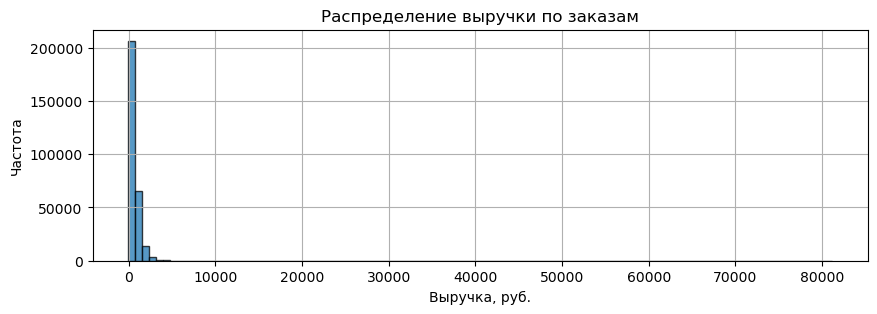

In [38]:
plt.figure(figsize=(10, 3))

df['revenue_rub'].plot(
    kind='hist',
    bins=100,
    alpha=0.75,
    edgecolor='black'
)

plt.title('Распределение выручки по заказам')
plt.xlabel('Выручка, руб.')
plt.ylabel('Частота')
plt.grid()

plt.show()

Видно, что в распределении выручки длинный правый хвост. Более того, он, скорее всего, связан с выбросами, от которых стоит избавиться.

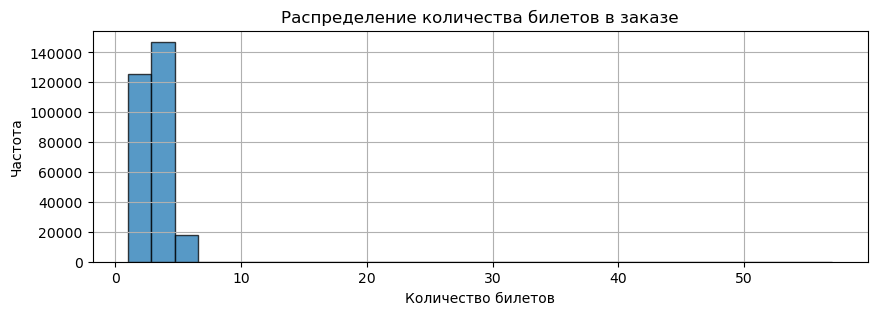

In [39]:
plt.figure(figsize=(10, 3))

df['tickets_count'].plot(
    kind='hist',
    bins=30,
    alpha=0.75,
    edgecolor='black'
)

plt.title('Распределение количества билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
plt.grid()

plt.show()

Аналогично имеются выбросы и в распределении количества билетов.

Проверим наблюдения по диаграмме размаха:

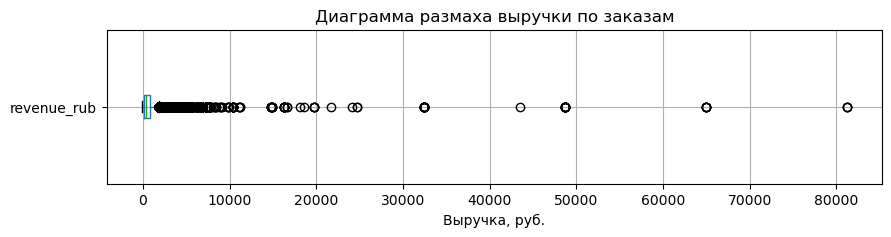

In [40]:
plt.figure(figsize=(10, 2))

df.boxplot(
    column='revenue_rub',
    vert=False
)

plt.title('Диаграмма размаха выручки по заказам')
plt.xlabel('Выручка, руб.')

plt.show()

Видим много крупных выбросов.

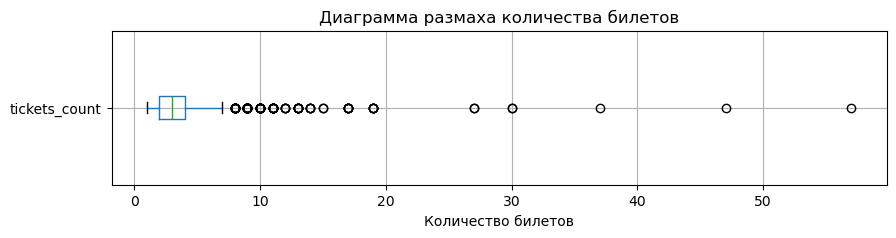

In [41]:
plt.figure(figsize=(10, 2))

df.boxplot(
    column='tickets_count',
    vert=False
)

plt.title('Диаграмма размаха количества билетов')
plt.xlabel('Количество билетов')

plt.show()

Для количества билетов выбросы также действительно есть, но не так много, как для выручки.

Были отмечены отрицательные значения в выручке. Посомтрим на них отдельно:


In [42]:
df[df['revenue_rub'] < 0][['order_id', 'currency_code', 'revenue', 'revenue_rub']].head(20)

,order_id,currency_code,revenue,revenue_rub
252,1594653,rub,-2.37,-2.37
4539,2360920,rub,-0.23,-0.23
4544,2361094,rub,-0.15,-0.15
8135,166780,rub,-1.86,-1.86
8136,166809,rub,-0.62,-0.62
11342,6620527,rub,-1.58,-1.58
11343,6620498,rub,-1.58,-1.58
11568,8333963,rub,-6.18,-6.18
11619,4930755,rub,-3.59,-3.59
11622,8350029,rub,-10.77,-10.77


И проверим, сколько их всего:

In [43]:
(df['revenue_rub'] < 0).sum()

np.int64(381)

В целом, отрицательных значений немного, а их природа может быть связана с возвратом билетов, отменой заказов или корректировкой платежа. В любом случае пока оснований для их удаления или замены не видно.

Отфильтруем значения в `revenue_rub` по 99 перцентилю. Зафиксируем порог:

In [44]:
revenue_99 = df['revenue_rub'].quantile(0.99)

revenue_99

np.float64(2628.4217390400004)

Создадим новый датафрейм с учетом фильтра и проверим, сколько строк удалилось:

In [45]:
df_filtered = df[df['revenue_rub'] <= revenue_99].copy()

len(df) - len(df_filtered)

2825

Или в процентах:

In [46]:
(1 - len(df_filtered) / len(df)) * 100

0.9720898383061893

Посотрим теперь на гистограмму и диаграмму размаха значений выручки без учета выбросов:

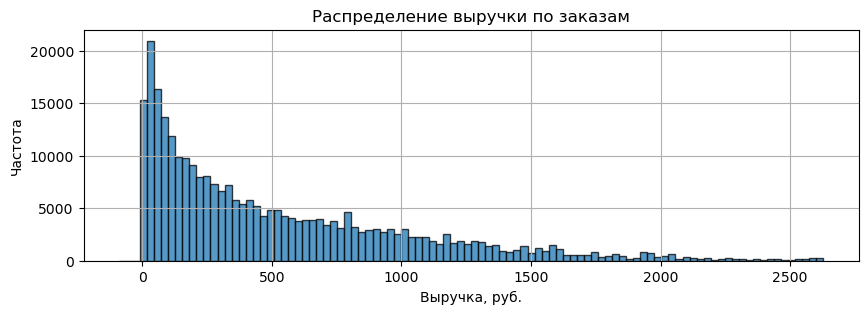

In [47]:
plt.figure(figsize=(10, 3))

df_filtered['revenue_rub'].plot(
    kind='hist',
    bins=100,
    alpha=0.75,
    edgecolor='black'
)

plt.title('Распределение выручки по заказам')
plt.xlabel('Выручка, руб.')
plt.ylabel('Частота')
plt.grid()

plt.show()

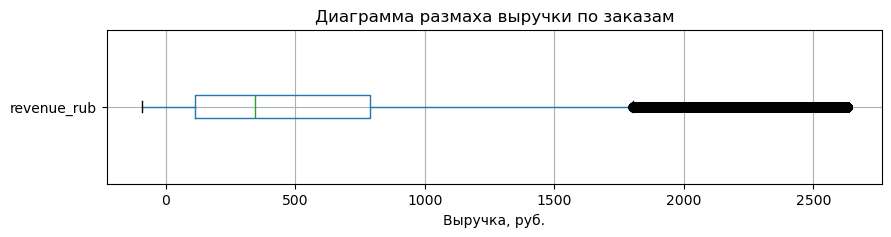

In [48]:
plt.figure(figsize=(10, 2))

df_filtered.boxplot(
    column='revenue_rub',
    vert=False
)

plt.title('Диаграмма размаха выручки по заказам')
plt.xlabel('Выручка, руб.')

plt.show()

Отфильтровывать количество билетов от выбросов, скорее всего, не стоит, т.к. с точки зрения бизнеса заказ на 20-50 билетов вполне возможен (корпоративный заказ, школьная экскурсия, спортивное мероприятие и т.п.). То есть большие значения билетов не обязательно являются ошибкой. Для выручки ситуация другая: несколько очень дорогих заказов сильно влияют на среднее и могут исказить анализ.

Также ради интереса рассмотрим статистику для количества дней от предыдущей покупки пользователя в столбце `days_since_prev`:

In [49]:
df_filtered['days_since_prev'].describe()

count    266060.000000
mean          3.223645
std          11.346488
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64

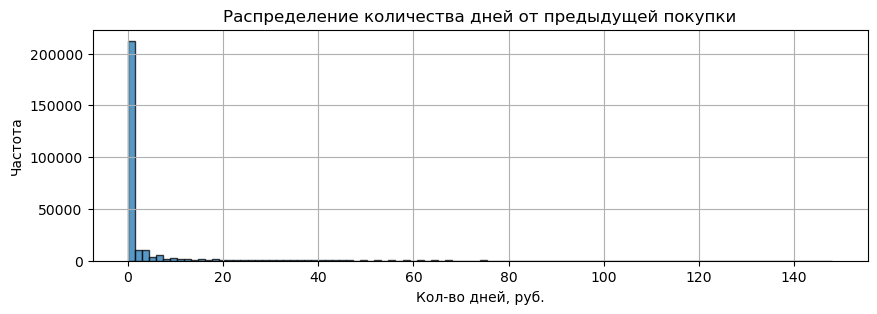

In [50]:
plt.figure(figsize=(10, 3))

df_filtered['days_since_prev'].plot(
    kind='hist',
    bins=100,
    alpha=0.75,
    edgecolor='black'
)

plt.title('Распределение количества дней от предыдущей покупки')
plt.xlabel('Кол-во дней, руб.')
plt.ylabel('Частота')
plt.grid()

plt.show()

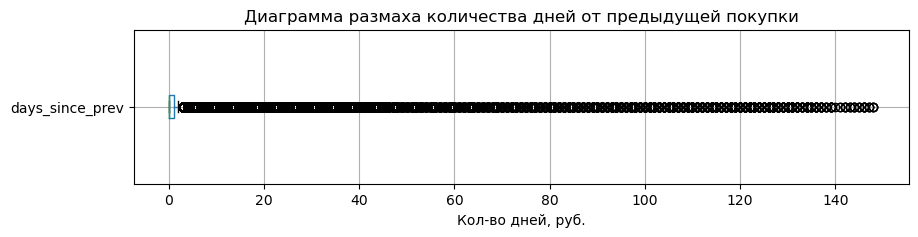

In [51]:
plt.figure(figsize=(10, 2))

df_filtered.boxplot(
    column='days_since_prev',
    vert=False
)

plt.title('Диаграмма размаха количества дней от предыдущей покупки')
plt.xlabel('Кол-во дней, руб.')

plt.show()

Видно, что большинство значений сосредоточены около маленьких значений, однако имеется сильно вытянутый правый хвост. Но эти выбросы в значениях вполне оправданы, т.к. количество дней от предыдыщей покупки могут быть любыми.

Выведем информацию о размере датафрейма до фильтрации и после, чтобы не потерять: 

In [52]:
print('До фильтрации:', len(df))
print('После фильтрации:', len(df_filtered))
print('Удалено строк:', len(df) - len(df_filtered))
print(
    'Удалено, %:',
    round((1 - len(df_filtered) / len(df)) * 100, 2)
)

До фильтрации: 290611
После фильтрации: 287786
Удалено строк: 2825
Удалено, %: 0.97


Посотрим на отфильтрованный датафрейм:

In [53]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 287786 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                287786 non-null  object        
 1   device_type_canonical  287786 non-null  category      
 2   order_id               287786 non-null  int32         
 3   order_dt               287786 non-null  datetime64[ns]
 4   order_ts               287786 non-null  datetime64[ns]
 5   currency_code          287786 non-null  category      
 6   revenue                287786 non-null  float64       
 7   tickets_count          287786 non-null  int8          
 8   days_since_prev        266060 non-null  float32       
 9   event_id               287786 non-null  int32         
 10  event_name             287786 non-null  object        
 11  event_type_main        287786 non-null  category      
 12  service_name           287786 non-null  category 

В ходе предобработки данных была выполнена подготовка показателей к дальнейшему анализу. Поскольку выручка в исходных данных была представлена в двух валютах (российских рублях и казахстанских тенге), данные были приведены к единой валюте - рублю. Для этого использовался отдельный датасет с курсами тенге к рублю за каждый день. На основе курса на дату заказа был рассчитан и добавлен новый столбец `revenue_rub`, содержащий выручку в российских рублях.

Была проведена проверка пропусков. Анализ показал, что отсутствующие значения содержатся только в столбце `days_since_prev` (21 933 записи или 7.55%), что соответствует ожидаемому результату выгрузки из SQL. В остальных столбцах пропуски отсутствуют.

Для снижения потребления памяти выполнена оптимизация типов данных: часть текстовых столбцов переведена в тип `category`, целочисленные и вещественные значения приведены к типам меньшей размерности.

Проверка категориальных значений (`device_type_canonical`, `currency_code`, `event_type_main`, `service_name`, `region_name`, `city_name`) не выявила категорий, обозначающих пропуски данных или отсутствие информации. Также не обнаружено явных дублей категорий, связанных с различиями в написании или регистре.

Исследование числовых столбцов показало наличие выраженного правого хвоста в распределении выручки. При максимальном значении выручки более 81 тыс. руб. 99-й перцентиль составил около 2628 руб., что свидетельствует о наличии экстремально крупных заказов (выручки). Эти данные были отфильтрованы по 99-му перцентилю столбца `revenue_rub`.

После фильтрации было удалено 2825 записей, что составляет около 0.97% от общего объёма данных. Таким образом, объём исключённых наблюдений невелик и не должен существенно повлиять на репрезентативность выборки.

Выбросы в столбце `tickets_count` дополнительно не удалялись, поскольку крупные заказы на десятки билетов могут отражать реальные бизнес-сценарии (групповые посещения, корпоративные мероприятия, экскурсии и другие коллективные покупки) и не являются очевидными ошибками данных.

В результате был подготовлен очищенный датасет `df_filtered`, содержащий данные с приведённой к единой валюте выручкой и без экстремальных значений в показателе выручки по заказу.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


Отсортируем данные по времени совершения заказа для каждого пользователя:

In [54]:
df_filtered = df_filtered.sort_values(by=['user_id', 'order_ts'])

Получим первый заказ каждого пользователя. Из него позже нужно будет взять устройство, регион, билетного партнёра, жанр мероприятия:

In [55]:
# Используем .first(), т.к. данные отсортирваны
first_orders = (
    df_filtered
    .groupby('user_id')
    .first()
    .reset_index()
)

Посмотрим на получившиеся данные:

In [56]:
first_orders.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,75.0,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,83.0,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
3,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск,917.83
4,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,16.0,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск,47.78


Начинаем создавать профиль пользователя. Добавим с помощью `.agg` несколько столбцов:

In [57]:
user_profile = (
    df_filtered
    .groupby('user_id')
    .agg(
        first_order_dt=('order_dt', 'min'), # дата первого заказа
        last_order_dt=('order_dt', 'max'), # дата последнего заказа
        orders_count=('order_id', 'count'), # количество заказов
        avg_revenue_rub=('revenue_rub', 'mean'), # средняя выручка
        avg_tickets=('tickets_count', 'mean'), # среднее количество билетов
        avg_days_since_prev=('days_since_prev', 'mean') # среднее время между заказами
    )
    .reset_index()
)

К `user_profile` добавим признаки из `first_orders`:

In [58]:
user_profile = user_profile.merge(
    first_orders[
        [
            'user_id',
            'device_type_canonical',
            'region_name',
            'service_name',
            'event_type_main'
        ]
    ],
    on='user_id',
    how='left'
)

Переименуем некоторые поля, которые относятся к первому заказу:

In [59]:
user_profile = user_profile.rename(
    columns={
        'device_type_canonical': 'first_device',
        'region_name': 'first_region',
        'service_name': 'first_service',
        'event_type_main': 'first_event_type'
    }
)

Добавим бинарные признаки `is_two` и `is_five`:

In [60]:
user_profile['is_two'] = (user_profile['orders_count'] >= 2).astype(int)

user_profile['is_five'] = (user_profile['orders_count'] >= 5).astype(int)

Посмотрим на первые строки профиля:

In [61]:
user_profile.head()

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets,avg_days_since_prev,first_device,first_region,first_service,first_event_type,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,1,0
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,1,0


И на информацию датафрейма:

In [62]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21854 entries, 0 to 21853
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              21854 non-null  object        
 1   first_order_dt       21854 non-null  datetime64[ns]
 2   last_order_dt        21854 non-null  datetime64[ns]
 3   orders_count         21854 non-null  int64         
 4   avg_revenue_rub      21854 non-null  float64       
 5   avg_tickets          21854 non-null  float64       
 6   avg_days_since_prev  13521 non-null  float32       
 7   first_device         21854 non-null  category      
 8   first_region         21854 non-null  category      
 9   first_service        21854 non-null  category      
 10  first_event_type     21854 non-null  category      
 11  is_two               21854 non-null  int64         
 12  is_five              21854 non-null  int64         
dtypes: category(4), datetime64[ns](

Профиль пользователя построен.

Понизим разрядность в новых числовых столбцах:

In [63]:
columns = ['orders_count', 'is_two', 'is_five']
for col in columns:
    user_profile[col] = pd.to_numeric(user_profile[col], downcast='integer')

user_profile['avg_tickets'] = pd.to_numeric(user_profile['avg_tickets'], downcast='float')

И выведем информацию о датафрейме:

In [64]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21854 entries, 0 to 21853
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              21854 non-null  object        
 1   first_order_dt       21854 non-null  datetime64[ns]
 2   last_order_dt        21854 non-null  datetime64[ns]
 3   orders_count         21854 non-null  int16         
 4   avg_revenue_rub      21854 non-null  float64       
 5   avg_tickets          21854 non-null  float32       
 6   avg_days_since_prev  13521 non-null  float32       
 7   first_device         21854 non-null  category      
 8   first_region         21854 non-null  category      
 9   first_service        21854 non-null  category      
 10  first_event_type     21854 non-null  category      
 11  is_two               21854 non-null  int8          
 12  is_five              21854 non-null  int8          
dtypes: category(4), datetime64[ns](

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

По описанию датафрейма `user_profile` мы уже знаем, что всего 21854 пользователя. Проверим по уникальным значениям:

In [65]:
user_profile['user_id'].nunique()

21854

Рассчитаем среднюю выручку с одного заказа, используя данные о профилях пользователя:

In [66]:
user_profile['avg_revenue_rub'].mean()

np.float64(544.398050897431)

Расчсчитаем долю пользователей, совершивших 2 и более заказа:

In [67]:
user_profile['is_two'].mean()

np.float64(0.6170952686007138)

В процентах:

In [68]:
user_profile['is_two'].mean() * 100

np.float64(61.709526860071385)

Расчсчитаем долю пользователей, совершивших 5 и более заказов:

In [69]:
user_profile['is_five'].mean()

np.float64(0.2900613160062231)

В процентах:

In [70]:
user_profile['is_five'].mean() * 100

np.float64(29.00613160062231)

Изучим статистические показатели по общему числу заказов:

In [71]:
user_profile['orders_count'].describe()

count    21854.000000
mean        13.168573
std        121.674800
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10181.000000
Name: orders_count, dtype: float64

По общему числу заказов сразу видно сильнейшую асимметрию:
- среднее значение = 121.6 заказа;
- медиана = 2 заказа;
- 75% пользователей сделали не более 5 заказов;
- максимальное значение = 10181 заказ.

Пользователь с 10 тысячами заказов за анализируемый период выглядит крайне подозрительно.

Рассчитаем перцентили для них:

In [72]:
user_profile['orders_count'].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.900      15.000
0.950      31.350
0.990     152.000
0.995     320.880
0.999    1461.969
Name: orders_count, dtype: float64

Можно отметить, что в распределении общего числа заказов наблюдаются экстремально высокие значения. При медиане в 2 заказа и 99-м перцентиле в 152 заказа максимальное значение составляет 10181 заказ. Такие пользователи могут представлять собой ошибки или иные нетипичные случаи и существенно влиять на средние показатели.

Сделаем фильтрацию по 99-му перцентилю и оценим её объём:

In [73]:
orders_99 = user_profile['orders_count'].quantile(0.99)

user_profile_filtered = user_profile[user_profile['orders_count'] <= orders_99].copy()

len(user_profile) - len(user_profile_filtered)

216

In [74]:
(1 - len(user_profile_filtered) / len(user_profile)) * 100

0.9883774137457668

Посомтрим на обновлёенную статистику:

In [75]:
user_profile_filtered['orders_count'].describe()

count    21638.000000
mean         6.501294
std         14.324031
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: orders_count, dtype: float64

Среднее до и после фильтрации:

In [76]:
print('До фильтрации:', user_profile['orders_count'].mean())

print('После фильтрации:', user_profile_filtered['orders_count'].mean())

До фильтрации: 13.168573258899972
После фильтрации: 6.501294019780016


Медиана до и после фильтрации:

In [77]:
print('До фильтрации:', user_profile['orders_count'].median())

print('После фильтрации:', user_profile_filtered['orders_count'].median())

До фильтрации: 2.0
После фильтрации: 2.0


Изучим статистические показатели по среднему числу билетов в заказе:

In [78]:
user_profile['avg_tickets'].describe()

count    21854.000000
mean         2.743129
std          0.913140
min          1.000000
25%          2.000000
50%          2.750000
75%          3.076923
max         11.000000
Name: avg_tickets, dtype: float64

Данные выгледят без аномалий.

Изучим статистические показатели по среднему количеству дней между покупками:

In [79]:
user_profile['avg_days_since_prev'].describe()

count    13521.000000
mean        15.836109
std         22.298199
min          0.000000
25%          1.000000
50%          8.000000
75%         20.400000
max        148.000000
Name: avg_days_since_prev, dtype: float64

Данные выглядет без аномалий.

Значения в `avg_tickets` можно оставить без изменений, т.к. mean = 2.74, median = 2.75, max = 11. 11 билетов в среднем на заказ не выглядит ошибкой и вполне объяснимо сценариями (семьи, группы, корпоративные мероприятия).

В среднем количестве дней между покупками в столбце `avg_days_since_prev` mean = 15.84, median = 8.00, max = 148.00. Но тут значения могут быть любыми: пользователь может совершать покупки как каждый день, так и пару раз за 5 месяцев.

Рассмотрим новый датафрейм:

In [80]:
user_profile_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21638 entries, 0 to 21853
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              21638 non-null  object        
 1   first_order_dt       21638 non-null  datetime64[ns]
 2   last_order_dt        21638 non-null  datetime64[ns]
 3   orders_count         21638 non-null  int16         
 4   avg_revenue_rub      21638 non-null  float64       
 5   avg_tickets          21638 non-null  float32       
 6   avg_days_since_prev  13305 non-null  float32       
 7   first_device         21638 non-null  category      
 8   first_region         21638 non-null  category      
 9   first_service        21638 non-null  category      
 10  first_event_type     21638 non-null  category      
 11  is_two               21638 non-null  int8          
 12  is_five              21638 non-null  int8          
dtypes: category(4), datetime64[ns](2), f

Таким образом, распределение количества заказов оказалось сильно скошенным вправо. При медиане в 2 заказа максимальное значение составило 10181 заказ, тогда как 99-й перцентиль равен 152 заказам. Это свидетельствует о наличии небольшого числа пользователей с экстремально высокой активностью или ошибкой в данных.

Для снижения влияния таких наблюдений на анализ была выполнена фильтрация по 99-му перцентилю. В результате было удалено 216 пользователей, что составляет около 0.99% выборки. Таким образом, для дальнейшего анализа сохранено более 99% пользователей.

После фильтрации максимальное количество заказов сократилось до 152.

Показатели среднего количества билетов в заказе и среднего количества дней между покупками были оставлены без изменений, поскольку выявленные большие значения могут отражать реальные особенности поведения пользователей и не свидетельствуют об ошибках в данных.

В дальнейшем для анализа используем отфильтрованный датасет `user_profile_filtered`.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


Посчитаем количество пользователей и их долю по типу их первого мероприятия:

In [81]:
first_event_type_dist = (
    user_profile_filtered['first_event_type']
    .value_counts()
    .reset_index()
)

first_event_type_dist.columns = ['first_event_type', 'users_count']

first_event_type_dist['share_pct'] = (
    first_event_type_dist['users_count']
    / first_event_type_dist['users_count'].sum()
    * 100
).round(2)

first_event_type_dist

,first_event_type,users_count,share_pct
0,концерты,9560,44.18
1,другое,5426,25.08
2,театр,4239,19.59
3,стендап,1110,5.13
4,спорт,794,3.67
5,выставки,414,1.91
6,ёлки,95,0.44


Посчитаем количество пользователей и их долю по типу устройства, с которого совершена первая покупка:

In [82]:
first_device_dist = (
    user_profile_filtered['first_device']
    .value_counts()
    .reset_index()
)

first_device_dist.columns = ['first_device', 'users_count']

first_device_dist['share_pct'] = (
    first_device_dist['users_count']
    / first_device_dist['users_count'].sum()
    * 100
).round(2)

first_device_dist

,first_device,users_count,share_pct
0,mobile,17924,82.84
1,desktop,3714,17.16


Посчитаем количество пользователей и их долю по региону проведения мероприятия из первого заказа. Выведем топ-10:

In [83]:
first_region_dist = (
    user_profile_filtered['first_region']
    .value_counts()
    .reset_index()
)

first_region_dist.columns = ['first_region', 'users_count']

first_region_dist['share_pct'] = (
    first_region_dist['users_count']
    / first_region_dist['users_count'].sum()
    * 100
).round(2)

first_region_dist.head(10)

,first_region,users_count,share_pct
0,Каменевский регион,7085,32.74
1,Североярская область,3767,17.41
2,Широковская область,1224,5.66
3,Озернинский край,675,3.12
4,Малиновоярский округ,525,2.43
5,Шанырский регион,500,2.31
6,Травяная область,488,2.26
7,Светополянский округ,457,2.11
8,Речиновская область,440,2.03
9,Яблоневская область,411,1.90


Посчитаем количество пользователей и их долю по билетному оператору, продавшему билеты на первый заказ:

In [84]:
first_service_dist = (
    user_profile_filtered['first_service']
    .value_counts()
    .reset_index()
)

first_service_dist.columns = ['first_service', 'users_count']

first_service_dist['share_pct'] = (
    first_service_dist['users_count']
    / first_service_dist['users_count'].sum()
    * 100
).round(2)

first_service_dist

,first_service,users_count,share_pct
0,Билеты без проблем,5186,23.97
1,Мой билет,2969,13.72
2,Лови билет!,2809,12.98
3,Билеты в руки,2559,11.83
4,Облачко,2177,10.06
5,Весь в билетах,1285,5.94
6,Лучшие билеты,1184,5.47
7,Прачечная,583,2.69
8,Край билетов,454,2.10
9,Дом культуры,356,1.65


Для наглядности визуализируем результаты для мероприятий и устройств:

<Figure size 800x400 with 0 Axes>

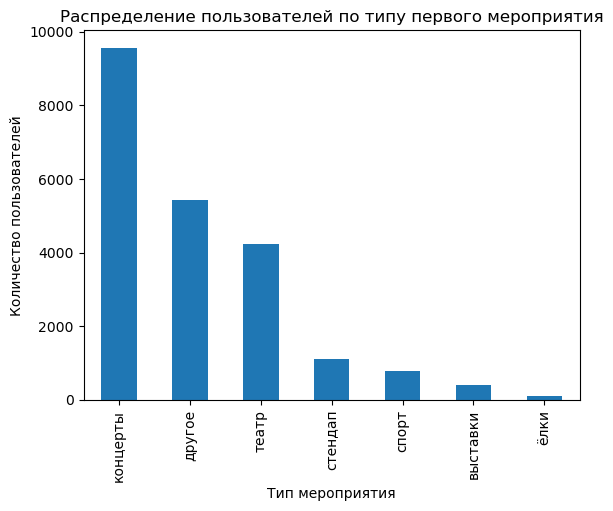

In [85]:
plt.figure(figsize=(8, 4))

first_event_type_dist.plot(
    x='first_event_type',
    y='users_count',
    kind='bar',
    legend=False
)

plt.title('Распределение пользователей по типу первого мероприятия')
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество пользователей')

plt.show()

<Figure size 800x400 with 0 Axes>

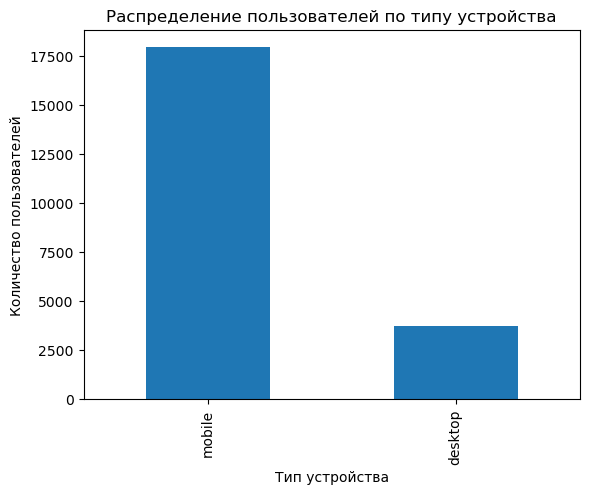

In [86]:
plt.figure(figsize=(8, 4))

first_device_dist.plot(
    x='first_device',
    y='users_count',
    kind='bar',
    legend=False
)

plt.title('Распределение пользователей по типу устройства')
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')

plt.show()

И для топ-10 по регионам и оператору:

<Figure size 800x400 with 0 Axes>

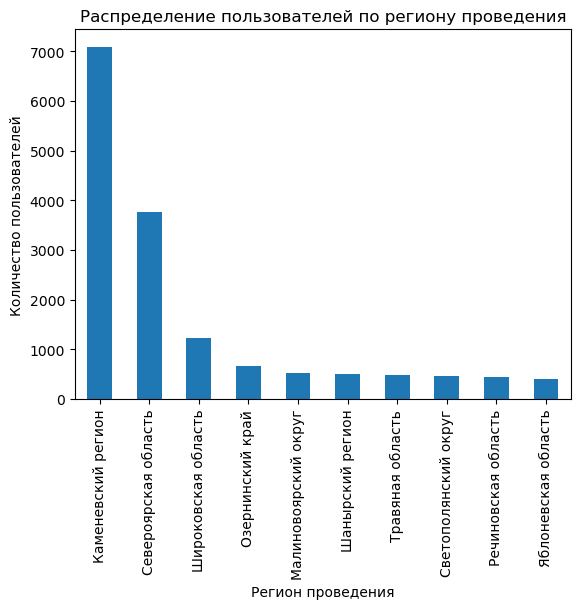

In [87]:
plt.figure(figsize=(8, 4))

first_region_dist.head(10).plot(
    x='first_region',
    y='users_count',
    kind='bar',
    legend=False
)

plt.title('Распределение пользователей по региону проведения')
plt.xlabel('Регион проведения')
plt.ylabel('Количество пользователей')

plt.show()

<Figure size 800x400 with 0 Axes>

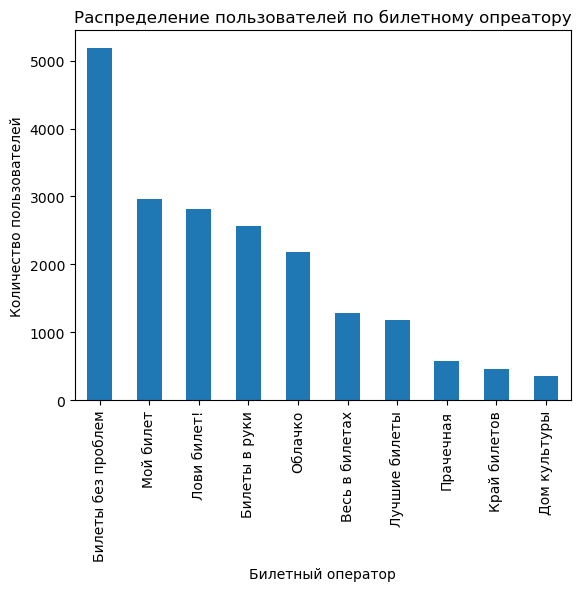

In [88]:
plt.figure(figsize=(8, 4))

first_service_dist.head(10).plot(
    x='first_service',
    y='users_count',
    kind='bar',
    legend=False
)

plt.title('Распределение пользователей по билетному опреатору')
plt.xlabel('Билетный оператор')
plt.ylabel('Количество пользователей')

plt.show()

По полученным результатам распределений можно отметить, что пользователи распределены неравномерно - имеются выраженные "точки входа".

**По типу первого мероприятия**

Наибольшая доля пользователей приобреала билеты на:
- `концерты` - 44.18%;
- `другое` - 25.08%;
- `театр` - 19.59%.

В сумме эти три категории формируют почти 89% всех пользователей. Остальные жанры имеют существенно меньшую долю (`стендап` - 5.13%, `спорт` - 3.67%, `выставки` - 1.91%, `ёлки` - 0.44%).

**По типу устройства первого заказа**

Распределение сильно смещено в сторону мобильных устройств:
- `mobile` - 82.84%;
- `desktop` - 17.16%.

Большинство пользователей совершают первый заказ именно с мобильных устройств.

**По региону первого заказа**

Распределение также нельзя назвать равномерным.

Лидируют:
- `Каменевский регион` - 32.74%;
- `Североярская область` - 17.41%.

Уже эти два региона обеспечивают более половины всех пользователей (50.15%). Доля остальных регионов существенно ниже и не превышает 6% каждая.

Это говорит о высокой концентрации клиентской базы в нескольких крупнейших регионах.

**По билетному оператору**

Здесь также наблюдается выраженная концентрация пользователей у нескольких партнёров:
- `Билеты без проблем` - 23.97%;
- `Мой билет` - 13.72%;
- `Лови билет!` - 12.98%;
- `Билеты в руки` - 11.83%;
- `Облачко` - 10.06%.

Только пять крупнейших операторов привели около 72.56% пользователей.

Остальные партнёры имеют значительно меньшую долю, а многие представлены лишь единичными наблюдениями.

Таким образом пользователи распределены по сегментам неравномерно. Можно выделить несколько ярко выраженных "точек входа" на платформу:
- первый заказ чаще всего связан с категорией `концерты`;
- основным устройством первого заказа является `мобильный телефон`;
- наибольший приток пользователей обеспечивают `Каменевский регион` и `Североярская область`;
- большинство пользователей приходит через ограниченное число крупных билетных операторов, прежде всего через `Билеты без проблем`, `Мой билет`, `Лови билет!`, `Билеты в руки` и `Облачко`.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Для каждого сегмента вычислим долю пользователей, совершивших два и более заказа, а также визуализируем результаты.

Начнем с сегмента по первому типу мероприятия:

In [89]:
event_return = (
    user_profile_filtered
    .groupby('first_event_type')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
    .sort_values('return_rate', ascending=False)
)

event_return['return_rate'] = (
    (event_return['return_rate'] * 100).round(2)
)

event_return

C:\Users\Anthony\AppData\Local\Temp\ipykernel_19348\3287627482.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('first_event_type')


,users_count,return_rate
first_event_type,,
выставки,414,64.01
театр,4239,63.39
концерты,9560,61.83
стендап,1110,60.90
другое,5426,59.62
спорт,794,55.79
ёлки,95,55.79


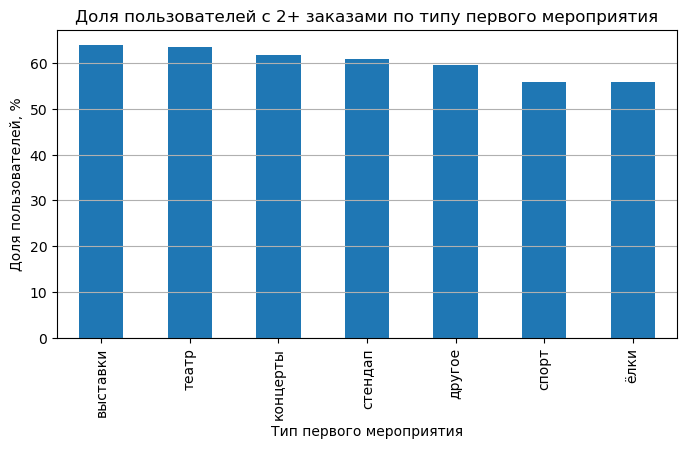

In [90]:
plt.figure(figsize=(8, 4))

event_return['return_rate'].plot(
    kind='bar',
    rot=90
)

plt.title('Доля пользователей с 2+ заказами по типу первого мероприятия')
plt.xlabel('Тип первого мероприятия')
plt.ylabel('Доля пользователей, %')
plt.grid(axis='y')

plt.show()

Для сегмента по типу устройства первого  заказа:

In [91]:
device_return = (
    user_profile_filtered
    .groupby('first_device')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
)

device_return['return_rate'] = (
    (device_return['return_rate'] * 100).round(2)
)

device_return

C:\Users\Anthony\AppData\Local\Temp\ipykernel_19348\3068065494.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('first_device')


,users_count,return_rate
first_device,,
desktop,3714,63.81
mobile,17924,60.81


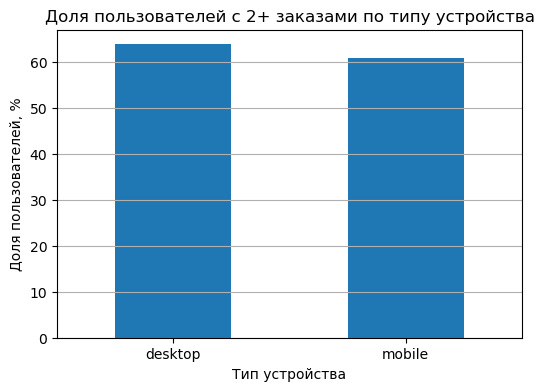

In [92]:
plt.figure(figsize=(6, 4))

device_return['return_rate'].plot(
    kind='bar',
    rot=0
)

plt.title('Доля пользователей с 2+ заказами по типу устройства')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей, %')
plt.grid(axis='y')

plt.show()

Для сегмента по региону проведения для первого заказа. Возьмем топ-10 таких регионов по числу пользователей:

In [93]:
region_return = (
    user_profile_filtered
    .groupby('first_region')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
)

region_return['return_rate'] = (
    (region_return['return_rate'] * 100).round(2)
)

region_return_top10 = (
    region_return
    .sort_values('users_count', ascending=False)
    .head(10)
)

region_return_top10

C:\Users\Anthony\AppData\Local\Temp\ipykernel_19348\2780372064.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('first_region')


,users_count,return_rate
first_region,,
Каменевский регион,7085,62.40
Североярская область,3767,63.82
Широковская область,1224,64.54
Озернинский край,675,55.26
Малиновоярский округ,525,56.00
Шанырский регион,500,67.20
Травяная область,488,61.48
Светополянский округ,457,65.65
Речиновская область,440,63.41


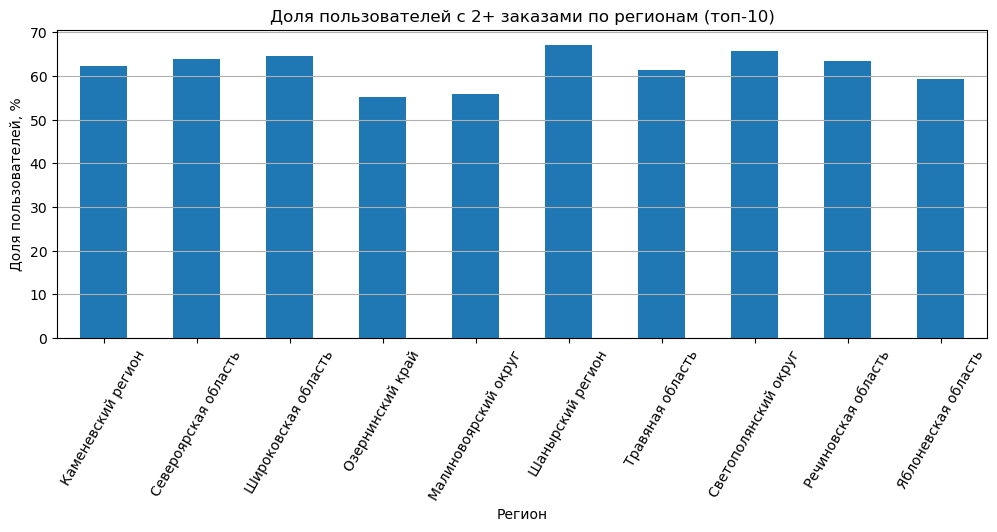

In [94]:
plt.figure(figsize=(12, 4))

region_return_top10['return_rate'].plot(
    kind='bar',
    rot=60
)

plt.title('Доля пользователей с 2+ заказами по регионам (топ-10)')
plt.xlabel('Регион')
plt.ylabel('Доля пользователей, %')
plt.grid(axis='y')

plt.show()

Для сегмента по билетному опреатору для первого заказа. Возьмем топ-10 таких операторов по числу пользователей:

In [95]:
service_return = (
    user_profile_filtered
    .groupby('first_service')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
)

service_return['return_rate'] = (
    (service_return['return_rate'] * 100).round(2)
)

service_return_top10 = (
    service_return
    .sort_values('users_count', ascending=False)
    .head(10)
)

service_return_top10

C:\Users\Anthony\AppData\Local\Temp\ipykernel_19348\1811140165.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('first_service')


,users_count,return_rate
first_service,,
Билеты без проблем,5186,60.41
Мой билет,2969,60.86
Лови билет!,2809,60.91
Билеты в руки,2559,62.72
Облачко,2177,61.28
Весь в билетах,1285,62.88
Лучшие билеты,1184,61.23
Прачечная,583,62.61
Край билетов,454,65.20


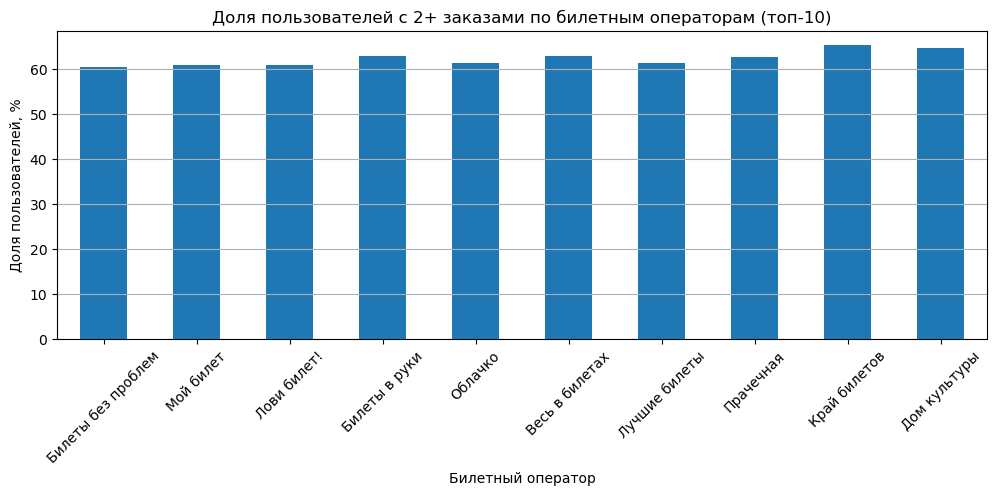

In [96]:
plt.figure(figsize=(12, 4))

service_return_top10['return_rate'].plot(
    kind='bar',
    rot=45
)

plt.title('Доля пользователей с 2+ заказами по билетным операторам (топ-10)')
plt.xlabel('Билетный оператор')
plt.ylabel('Доля пользователей, %')
plt.grid(axis='y')

plt.show()

Средняя доля пользователей, совершивших 2 и более заказа, по всей выборке составляет:

In [97]:
(user_profile_filtered['is_two'].mean() * 100).round(2)

np.float64(61.33)

По всей выборке доля пользователей, совершивших 2 и более заказа, составляет 61.33%. Сравним с этим значением отдельные сегменты пользователей.

**По типу первого мероприятия** наиболее высокий уровень возврата наблюдается у пользователей, впервые посетивших `выставки` (64.01%) и `театр` (63.39%). Также немного выше среднего показатель у пользователей, начавших взаимодействие с платформой через `концерты` (61.83%). Напротив, пользователи, чей первый заказ был связан со `спортом` или праздничной `ёлкой` (55.79%), возвращаются заметно реже среднего уровня. Следует учитывать, что сегменты `выставки` (414 пользователей) и особенно `ёлки` (95 пользователей) существенно меньше остальных, поэтому их показатели могут быть менее репрезеннтативными.

**По типу устройства первого заказа** различия невелики, однако пользователи, совершившие первый заказ с `desktop` (63.81%), возвращаются несколько чаще пользователей с `mobile` (60.81%). При этом мобильный канал остаётся основной точкой входа, поскольку через него пришло более 80% пользователей.

**По регионам** среди десяти крупнейших сегментов наиболее высокая доля возвратов наблюдается в `Шанырском регионе` (67.20%), `Светополянском округе` (65.65%) и `Широковской области` (64.54%). Самые низкие показатели среди крупнейших регионов зафиксированы в `Озернинском крае` (55.26%) и `Малиновоярском округе` (56.00%). Таким образом, отдельные регионы действительно демонстрируют заметно более высокий уровень удержания пользователей по сравнению со средним значением.

**По билетным операторам** среди крупнейших сегментов наиболее высокий уровень возврата показывают пользователи, впервые купившие билеты через `Край билетов` (65.20%) и `Дом культуры` (64.61%). Также выше среднего значения находятся `Весь в билетах` (62.88%), `Билеты в руки` (62.72%) и `Прачечная` (62.61%). В то же время различия между крупнейшими операторами не слишком велики: большинство значений находятся в диапазоне от 60% до 65%.

Распределение возвратов по сегментам показывает, что успешные "точки входа" действительно существуют. Наиболее заметно влияние оказывают тип первого мероприятия (`выставки` и `театр`), регион первого заказа (`Шанырский регион`) и в меньшей степени билетный оператор (`Край билетов`). При этом различия между сегментами чаще всего составляют несколько процентных пунктов относительно среднего уровня возврата в 61.33%.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

**Гипотеза 1**

Фактически эта гипотеза проверена в задаче 4.1.2 выше. Выведем полученную информацию для `спорта` и `концертов`:

In [98]:
event_return.loc[['спорт', 'концерты']]

,users_count,return_rate
first_event_type,,
спорт,794,55.79
концерты,9560,61.83


Из результата следует:
- пользователи `концертов` возвращаются чаще;
- пользователи `спорта` возвращаются реже среднего по выборке (61.33%).

Гипотеза о том, что пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты, не подтверждается. Доля пользователей с повторными заказами среди сегмента `спорт` составляет 55.79%, тогда как среди пользователей, впервые посетивших `концерты`, - 61.83%. Таким образом, концерты являются более успешной "точкой входа" с точки зрения дальнейшего возврата пользователей на платформу.

**Гипотеза 2**

Часть результата уже получена выше при решении задачи 4.1.2. Рассмотрим таблицу по регионам, содержащую количество пользователей в регионе и долю пользователей, совершивших 2 и более заказа:

In [99]:
region_return.sort_values(by='users_count')

,users_count,return_rate
first_region,,
Яснопольский округ,1,0.00
Сосноводолинская область,1,0.00
Верхозёрский край,1,100.00
Залесский край,2,50.00
Светолесский край,2,50.00
...,...,...
Малиновоярский округ,525,56.00
Озернинский край,675,55.26
Широковская область,1224,64.54


Для проверки гипотезы можно рассчитать корреляцию между показателями. Перед расчетом корреляции посмотрим на распределение количества пользователей по регионам:

In [100]:
region_return['users_count'].describe()

count      81.000000
mean      267.135802
std       888.496268
min         1.000000
25%        22.000000
50%        52.000000
75%       203.000000
max      7085.000000
Name: users_count, dtype: float64

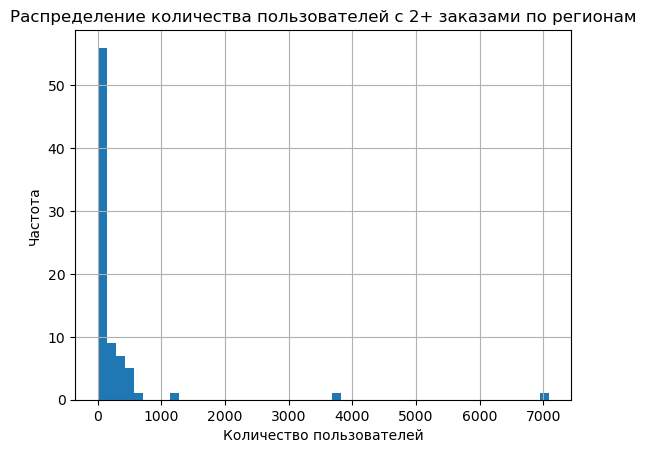

In [101]:
region_return['users_count'].plot(
    kind='hist',
    bins=50
)

plt.title('Распределение количества пользователей с 2+ заказами по регионам')
plt.xlabel('Количество пользователей')
plt.ylabel('Частота')
plt.grid()

plt.show()

По результатам видно, что распределение регионов по числу пользователей сильно неравномерно: есть два крупнейших региона, которые значительно опережают остальные, а большинство регионов имеют сравнительно небольшое количество пользователей - наблюдается длинный правый хвост.

То есть распределение далеко от нормального, поэтому для оценки связи между признаками целесообразно использовать **коэффициент корреляции Спирмена**, который не требует нормальности распределения и хорошо работает при монотонных зависимостях:

In [102]:
region_return[['users_count', 'return_rate']].corr(
    method='spearman'
)

,users_count,return_rate
users_count,1.000000,0.311099
return_rate,0.311099,1.000000


Дополнительно построим диаграмму рассеяния:

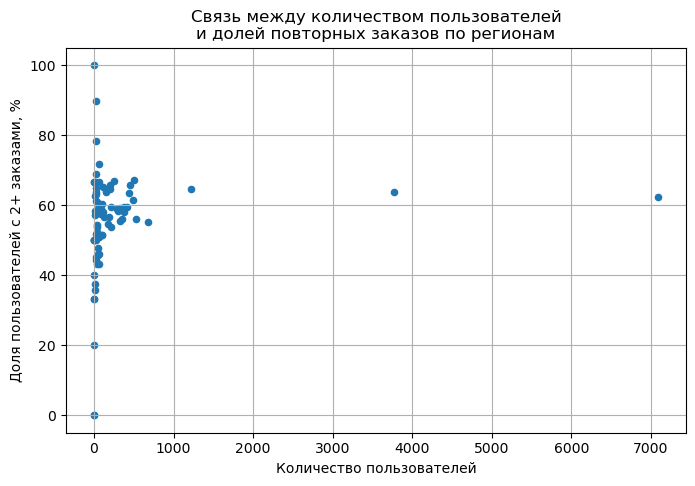

In [103]:
region_return.plot(
    kind='scatter',
    x='users_count',
    y='return_rate',
    figsize=(8, 5)
)

plt.title(
    'Связь между количеством пользователей\nи долей повторных заказов по регионам'
)
plt.xlabel('Количество пользователей')
plt.ylabel('Доля пользователей с 2+ заказами, %')
plt.grid()

plt.show()

Таким образом, для проверки гипотезы была рассчитана корреляция Спирмена между количеством пользователей в регионе и долей пользователей, совершивших два и более заказа. Полученное значение коэффициента составило **0.31**.

Коэффициент положительный, что говорит о наличии связи: в более крупных регионах доля возвратов в среднем действительно может быть несколько выше. Однако величина коэффициента невелика, поэтому связь нельзя назвать сильной.

Диаграмма рассеяния также показывает отсутствие выраженной линейной зависимости. Точки распределены достаточно широко, а среди регионов с небольшим количеством пользователей наблюдается значительный разброс значений доли повторных заказов.

Таким образом, гипотеза получает частичное подтверждение.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


Построим сравнительные гистограммы распредления средней выручки с билеты для пользователей с одним и 2 и более заказами:

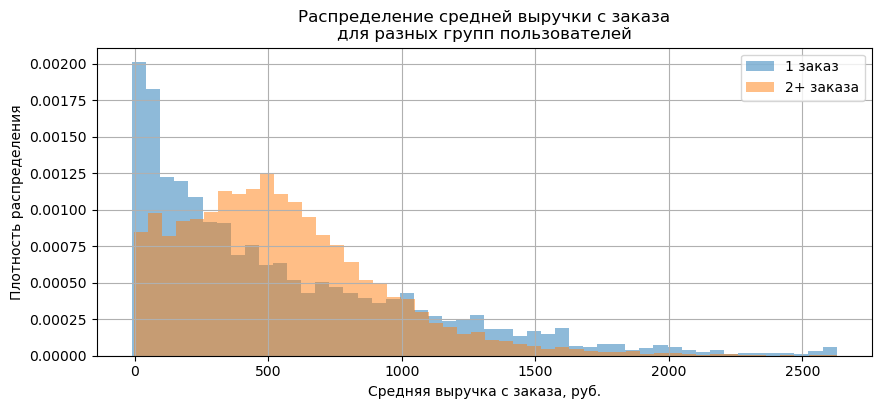

In [104]:
plt.figure(figsize=(10, 4))

for value in user_profile_filtered['is_two'].unique():
    user_profile_filtered.loc[
        user_profile_filtered['is_two'] == value,
        'avg_revenue_rub'
    ].plot(
        kind='hist',
        bins=50,
        alpha=0.5,
        density=True,
        label='2+ заказа' if value == 1 else '1 заказ'
    )

plt.title(
    'Распределение средней выручки с заказа\nдля разных групп пользователей'
)
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid()

plt.show()

Дополнительно выведем описательную статистику по группам:

In [105]:
user_profile_filtered.groupby('is_two')['avg_revenue_rub'].describe()

,count,mean,std,min,25%,50%,75%,max
is_two,,,,,,,,
0,8368.0,545.295642,519.514097,-10.770,132.070000,378.030000,830.3175,2628.421739
1,13270.0,544.337170,369.354468,-5.385,270.814375,495.772429,745.1655,2628.421739


По графику и статистике различия между группами прослеживаются.

Для пользователей с одним заказом наибольшая концентрация наблюдается при низкой средней выручке - примерно до 200-300 руб. Медиана составляет 378 руб., то есть половина таких пользователей имеет среднюю выручку ниже этого значения. 25% пользователей имеют среднюю выручку менее 132 руб. Распределение сильно смещено в сторону небольших заказов.

Для пользователей с двумя и более заказами основная масса пользователей сосредоточена в диапазоне примерно 300-800 руб. Медиана составляет 496 руб., что заметно выше, чем у пользователей с одним заказом. Нижний квартиль равен 271 руб., то есть даже 25% пользователей с двумя и более заказами тратят больше, чем аналогичная доля пользователей с одним заказом. Распределение выглядит более компактным и смещённым вправо относительно первой группы.

То есть, в целом, различия наблюдаются. Несмотря на то что средние значения практически совпадают (545 руб. для пользователей с одним заказом и 544 руб. для пользователей с двумя и более заказами), среднее значение здесь оказывается не очень информативным из-за сильной асимметрии распределений и наличия длинного правого хвоста.

Более показательны медианы и сравнительная гистограмма, которая также показывает, что среди пользователей с одним заказом существенно выше доля небольших покупок, тогда как вернувшиеся пользователи чаще совершают заказы со средней выручкой в несколько сотен рублей.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


Построим сравнительные гистограммы распредления средней выручки с билеты для пользователей с 2-4 заказами и 5 и более заказами, а также выведем описательную статистику. Для  выявления этих групп используем уже созданные признаки: 2-4 заказа - `is_two == 1` и `is_five == 0`, 5 и более заказов - `is_five == 1`:

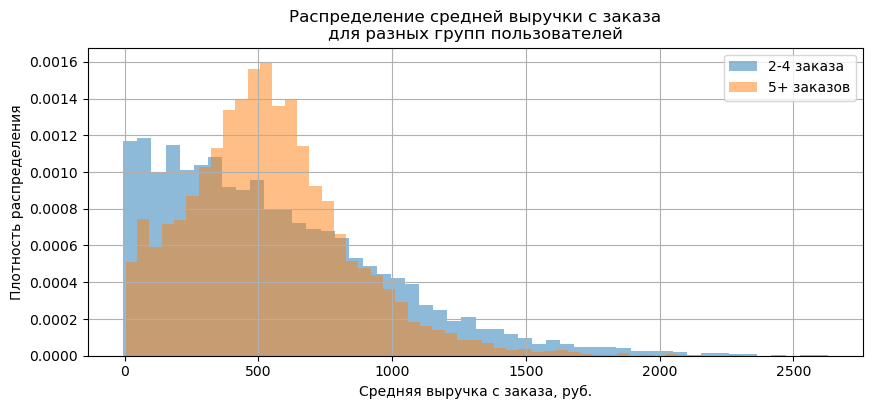

In [106]:
plt.figure(figsize=(10, 4))

user_profile_filtered.loc[
    (user_profile_filtered['is_two'] == 1)
    & (user_profile_filtered['is_five'] == 0),
    'avg_revenue_rub'
].plot(
    kind='hist',
    bins=50,
    alpha=0.5,
    density=True,
    label='2-4 заказа'
)

user_profile_filtered.loc[
    user_profile_filtered['is_five'] == 1,
    'avg_revenue_rub'
].plot(
    kind='hist',
    bins=50,
    alpha=0.5,
    density=True,
    label='5+ заказов'
)

plt.title(
    'Распределение средней выручки с заказа\nдля разных групп пользователей'
)
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid()

plt.show()

In [107]:
user_profile_filtered.loc[
    (
        ((user_profile_filtered['is_two'] == 1)
         & (user_profile_filtered['is_five'] == 0))
        | (user_profile_filtered['is_five'] == 1)
    )
].groupby('is_five')['avg_revenue_rub'].describe()

,count,mean,std,min,25%,50%,75%,max
is_five,,,,,,,,
0,7147.0,551.572386,420.197691,-5.385,218.428750,471.266667,798.550000,2628.421739
1,6123.0,535.891950,299.089582,0.000,330.456122,512.650613,700.809038,2299.869022


По гистограмме видно, что распределение пользователей с 5 и более заказами смещено вправо относительно группы 2-4 заказа в диапазоне примерно от 300 до 700 рублей. При этом распределение становится более концентрированным вокруг средних значений. У пользователей с 2-4 заказами распределение более растянутое, а доля пользователей с очень высокой средней выручкой заметно больше.

Средняя выручка с заказа у пользователей с 2-4 заказами составляет 552 руб., у пользователей с 5 и более заказами - 536 руб. Медианная выручка, наоборот, выше у пользователей с 5 и более заказами (513 руб. против 471 руб.). Разброс значений существенно выше в группе 2-4 заказа (стандартное отклонение 420 против 299). Максимальная средняя выручка также выше у пользователей с 2-4 заказами (2628 руб. против 2300 руб.).

Разница между средним и медианой говорит о том, что в группе пользователей с 2-4 заказами присутствует больше заказов с очень высокой средней выручкой, которые повышают среднее значение. У пользователей с 5 и более заказами распределение более устойчивое и сосредоточено вокруг средних значений.

Таким образом, существенных различий по средней выручке с заказа между пользователями, совершившими 2-4 заказа и 5 и более заказов, не наблюдается. Однако можно отметить, что пользователи с 5 и более заказами демонстрируют более стабильный уровень средней выручки, тогда как среди пользователей с 2-4 заказами чаще встречаются случаи очень высокой средней выручки с заказа.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Посмотрим на описательную статистику (только у меня это `avg_tickets`, а не `avg_tickets_count`):

In [108]:
user_profile_filtered['avg_tickets'].describe()

count    21638.000000
mean         2.743319
std          0.917477
min          1.000000
25%          2.000000
50%          2.750000
75%          3.095238
max         11.000000
Name: avg_tickets, dtype: float64

Построим гистограмму распределения:

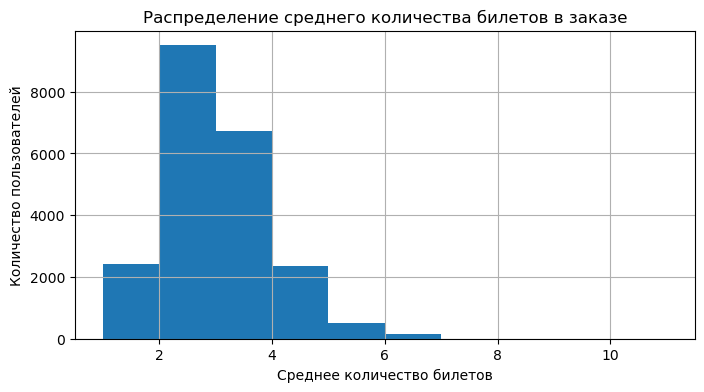

In [109]:
plt.figure(figsize=(8, 4))

user_profile_filtered['avg_tickets'].plot(
    kind='hist',
    bins=10
)

plt.title('Распределение среднего количества билетов в заказе')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
plt.grid()

plt.show()

И оценим значения по диаграмме размаха:

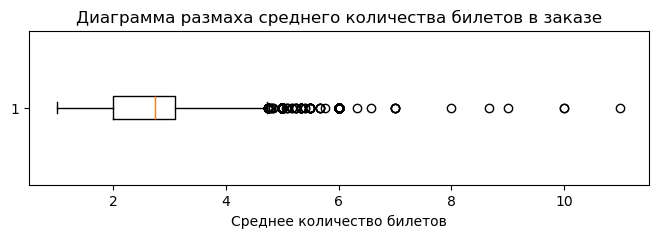

In [110]:
plt.figure(figsize=(8, 2))

plt.boxplot(user_profile_filtered['avg_tickets'], vert=False)

plt.title('Диаграмма размаха среднего количества билетов в заказе')
plt.xlabel('Среднее количество билетов')

plt.show()

Среднее количество билетов в заказе составляет 2.74 билета, медианное значение - 2.75 билета. Практически одинаковые значения среднего и медианы говорят о том, что распределение в целом достаточно сбалансировано и не имеет сильного перекоса. Это видно по гистограмме распределения - основная масса наблюдений сосредоточена в интервале от 2 до 4 билетов, а с ростом среднего количества билетов число пользователей быстро уменьшается. Пользователи, которые в среднем покупают более 5 билетов за заказ, встречаются достаточно редко.

Диаграмма размаха показывает наличие отдельных высоких значений. Максимальное значение составляет 11 билетов, что значительно превышает верхний квартиль (3.10 билета). Такие наблюдения можно считать выбросами, однако их количество невелико и они выглядят правдоподобно с предметной точки зрения: некоторые пользователи действительно могут приобретать билеты сразу для семьи или компании.

Далее, разделим пользователей на несколько сегментов по среднему количеству билетов в заказе. Для этого создадим категориальный признак с помощью `pd.cut()`, а затем посчитаем количество пользователей и долю вернувшихся (`is_two`):

In [111]:
user_profile_filtered['tickets_group'] = pd.cut(
    user_profile_filtered['avg_tickets'],
    bins=[1, 2, 3, 5, 12],
    labels=[
        '1-2 билета',
        '2-3 билета',
        '3-5 билетов',
        '5+ билетов'
    ],
    include_lowest=True
)

user_profile_filtered.head()

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets,avg_days_since_prev,first_device,first_region,first_service,first_event_type,is_two,is_five,tickets_group
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,0,0,3-5 билетов
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,1,0,2-3 билета
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,1,0,2-3 билета
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,0,0,3-5 билетов
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,1,0,1-2 билета


In [112]:
tickets_return = (
    user_profile_filtered
    .groupby('tickets_group')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
)

tickets_return['return_rate'] = (
    tickets_return['return_rate'] * 100
).round(2)

tickets_return

C:\Users\Anthony\AppData\Local\Temp\ipykernel_19348\1643159625.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('tickets_group')


,users_count,return_rate
tickets_group,,
1-2 билета,6160,40.15
2-3 билета,9935,74.28
3-5 билетов,5349,62.70
5+ билетов,194,32.47


Виуализируем результат:

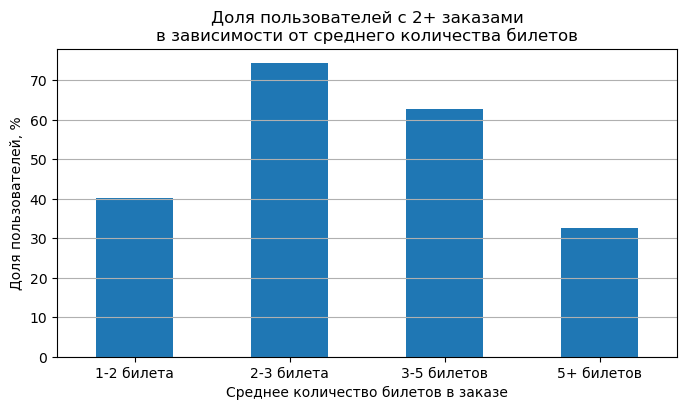

In [113]:
plt.figure(figsize=(8, 4))

tickets_return['return_rate'].plot(
    kind='bar',
    rot=0
)

plt.title(
    'Доля пользователей с 2+ заказами\nв зависимости от среднего количества билетов'
)
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Доля пользователей, %')
plt.grid(axis='y')

plt.show()

По полученным результатам можно отметить, что пользователи распределены по сегментам неравномерно. Наиболее крупным сегментом являются пользователи, которые в среднем покупают от 2 до 3 билетов за заказ - 9935 пользователей. Далее следуют 1-2 билета (6160 пользователей) и 3-5 билетов (5349 пользователей). Сегмент пользователей, приобретающих 5 и более билетов, крайне малочисленен - всего 194 пользователя. То есть основная масса пользователей сосредоточена в диапазоне от 1 до 5 билетов за заказ.

Доля пользователей, совершивших 2 и более заказа, заметно различается между сегментами. Наибольшая доля повторных покупок наблюдается в сегменте 2-3 билета - 74.28%. Это существенно выше среднего значения по выборке (61.33%), поэтому данный сегмент можно считать наиболее успешным с точки зрения удержания пользователей.

Сегмент 3-5 билетов также показывает результат выше среднего - 62.70%, однако его преимущество уже значительно менее выражено.

Наиболее низкая доля повторных покупок наблюдается в сегментах 5+ билетов - 32.47% и 1-2 билета - 40.15%. Особенно осторожно следует интерпретировать результат для сегмента 5+ билетов, поскольку он содержит всего 194 пользователя. Из-за небольшого объёма группы полученная доля может быть нестабильной и сильнее зависеть от отдельных наблюдений. В то же время низкий уровень возвратов в сегменте 1-2 билета выглядит более надёжным выводом, поскольку группа достаточно крупная (6160 пользователей).

Результат позволяет предположить, что наиболее лояльными оказываются пользователи, совершающие покупки для небольшой компании или семьи, тогда как покупка большего количества билетов не связана с более высокой вероятностью повторного заказа.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


Для выделения дня недели используем уже имеющийся столбец `first_order_dt` из профиля пользователей. Создадим новый признак для названия дней недели:

In [114]:
user_profile_filtered['first_order_weekday'] = (
    user_profile_filtered['first_order_dt']
    .dt.dayofweek
)

user_profile_filtered.head()

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets,avg_days_since_prev,first_device,first_region,first_service,first_event_type,is_two,is_five,tickets_group,first_order_weekday
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,0,0,3-5 билетов,1
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,1,0,2-3 билета,1
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,1,0,2-3 билета,5
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,0,0,3-5 билетов,3
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,1,0,1-2 билета,6


Заменим номера дней недели на названия:

In [115]:
weekday_names = {
    0: 'Понедельник',
    1: 'Вторник',
    2: 'Среда',
    3: 'Четверг',
    4: 'Пятница',
    5: 'Суббота',
    6: 'Воскресенье'
}

user_profile_filtered['first_order_weekday'] = (
    user_profile_filtered['first_order_weekday']
    .map(weekday_names)
)

user_profile_filtered.head()

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets,avg_days_since_prev,first_device,first_region,first_service,first_event_type,is_two,is_five,tickets_group,first_order_weekday
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,0,0,3-5 билетов,Вторник
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,1,0,2-3 билета,Вторник
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,1,0,2-3 билета,Суббота
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,0,0,3-5 билетов,Четверг
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,1,0,1-2 билета,Воскресенье


Рассчитаем число пользователей и долю повторных покупок:

In [116]:
weekday_return = (
    user_profile_filtered
    .groupby('first_order_weekday')
    .agg(
        users_count=('user_id', 'count'),
        return_rate=('is_two', 'mean')
    )
)

weekday_return['return_rate'] = (
    weekday_return['return_rate'] * 100
).round(2)

weekday_return

,users_count,return_rate
first_order_weekday,,
Воскресенье,2777,60.03
Вторник,3176,61.90
Понедельник,2930,63.04
Пятница,3259,59.83
Среда,3057,62.19
Суббота,3326,62.81
Четверг,3113,59.43


Поменяем порядок:

In [117]:
weekday_order = [
    'Понедельник',
    'Вторник',
    'Среда',
    'Четверг',
    'Пятница',
    'Суббота',
    'Воскресенье'
]

weekday_return = weekday_return.reindex(weekday_order)

weekday_return

,users_count,return_rate
first_order_weekday,,
Понедельник,2930,63.04
Вторник,3176,61.90
Среда,3057,62.19
Четверг,3113,59.43
Пятница,3259,59.83
Суббота,3326,62.81
Воскресенье,2777,60.03


Визуализируем количество пользователей:

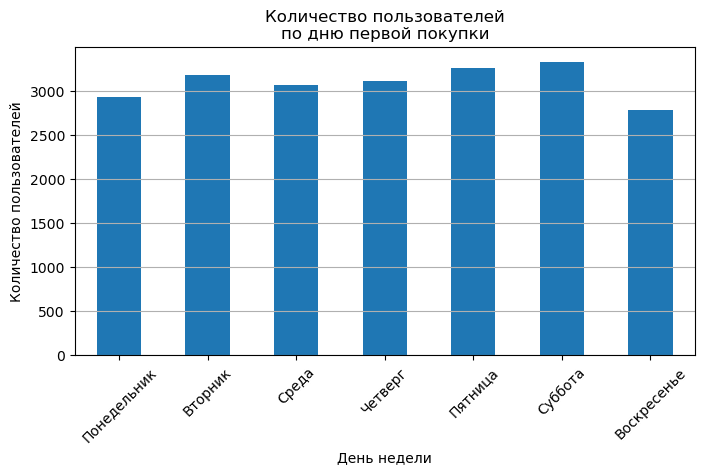

In [118]:
plt.figure(figsize=(8, 4))

weekday_return['users_count'].plot(
    kind='bar',
    rot=45
)

plt.title(
    'Количество пользователей\nпо дню первой покупки'
)
plt.xlabel('День недели')
plt.ylabel('Количество пользователей')
plt.grid(axis='y')

plt.show()

Визуализируем долю повторных заказов:

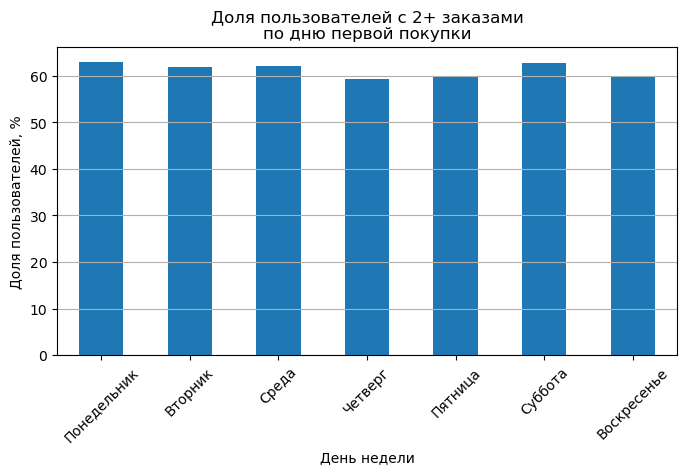

In [119]:
plt.figure(figsize=(8, 4))

weekday_return['return_rate'].plot(
    kind='bar',
    rot=45
)

plt.title(
    'Доля пользователей с 2+ заказами\nпо дню первой покупки'
)
plt.xlabel('День недели')
plt.ylabel('Доля пользователей, %')
plt.grid(axis='y')

plt.show()

Распределение пользователей по дням недели достаточно равномерное: в каждом сегменте находится от 2777 до 3326 пользователей. Это означает, что все группы имеют сопоставимый размер.

Доля пользователей, совершивших 2 и более заказа, колеблется от 59.43% до 63.04%:
- Понедельник - 63.04%;
- Суббота - 62.81%;
- Среда - 62.19%;
- Вторник - 61.90%;
- Воскресенье - 60.03%;
- Пятница - 59.83%;
- Четверг - 59.43%.

Среднее значение по всей выборке составляет 61.33%. Большинство дней недели отклоняются от него всего на 1-2 процента.

Можно отметить, что пользователи, совершившие первый заказ в понедельник или субботу, возвращаются немного чаще среднего уровня, тогда как пользователи, пришедшие в четверг и пятницу, возвращаются немного реже. Однако различия между сегментами невелики.

Таким образом, день недели первой покупки не является сильным фактором, влияющим на вероятность возврата пользователя. Хотя небольшие различия между днями наблюдаются, они существенно меньше тех различий, которые ранее были обнаружены для отдельных типов мероприятий, регионов или сегментов по количеству билетов в заказе. Поэтому влияние дня недели на повторные покупки можно считать слабым.

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


Используем признак `avg_days_since_prev` - среднее количество дней между заказами для каждого пользователя.

Сравним распределения и статистику для двух групп:
- пользователи с 2-4 заказами (`is_two == 1` и `is_five == 0`);
- пользователи с 5 и более заказами (`is_five == 1`):

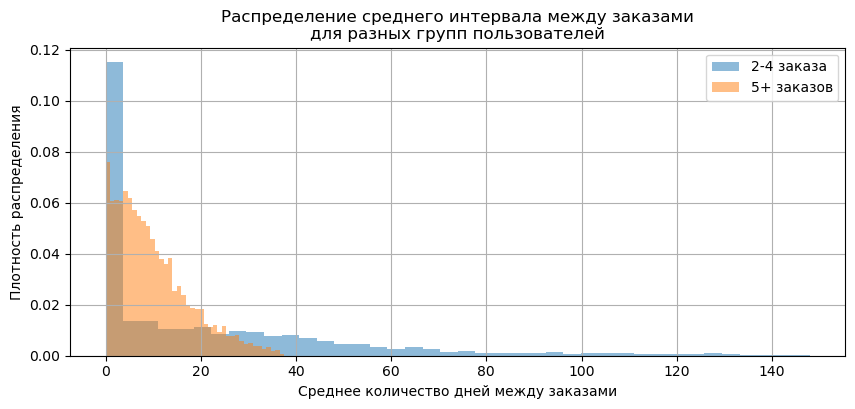

In [120]:
plt.figure(figsize=(10, 4))

user_profile_filtered.loc[
    (user_profile_filtered['is_two'] == 1)
    & (user_profile_filtered['is_five'] == 0),
    'avg_days_since_prev'
].plot(
    kind='hist',
    bins=40,
    alpha=0.5,
    density=True,
    label='2-4 заказа'
)

user_profile_filtered.loc[
    user_profile_filtered['is_five'] == 1,
    'avg_days_since_prev'
].plot(
    kind='hist',
    bins=40,
    alpha=0.5,
    density=True,
    label='5+ заказов'
)

plt.title(
    'Распределение среднего интервала между заказами\nдля разных групп пользователей'
)
plt.xlabel('Среднее количество дней между заказами')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid()

plt.show()

In [121]:
user_profile_filtered.loc[
    (
        ((user_profile_filtered['is_two'] == 1)
         & (user_profile_filtered['is_five'] == 0))
        | (user_profile_filtered['is_five'] == 1)
    )
].groupby('is_five')['avg_days_since_prev'].describe()

,count,mean,std,min,25%,50%,75%,max
is_five,,,,,,,,
0,7147.0,21.317884,28.480288,0.0,0.000000,9.000000,34.000000,148.0
1,6123.0,9.901352,7.803742,0.0,3.884034,8.117647,14.118055,37.5


Попробуем исследовать связь между интервалом и возвратом через сегменты.

Разобьем пользователей на группы по среднему интервалу между заказами:

In [122]:
user_profile_filtered['days_group'] = pd.cut(
    user_profile_filtered['avg_days_since_prev'],
    bins=[0, 7, 14, 30, 150],
    labels=[
        'до 7 дней',
        '7-14 дней',
        '14-30 дней',
        '30+ дней'
    ],
    include_lowest=True
)

user_profile_filtered.head()

,user_id,first_order_dt,last_order_dt,orders_count,avg_revenue_rub,avg_tickets,avg_days_since_prev,first_device,first_region,first_service,first_event_type,is_two,is_five,tickets_group,first_order_weekday,days_group
0,0002849b70a3ce2,2024-08-20,2024-08-20,1,1521.940000,4.000000,NaN,mobile,Каменевский регион,Край билетов,театр,0,0,3-5 билетов,Вторник,NaN
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,2,774.010000,3.000000,75.0,mobile,Каменевский регион,Мой билет,выставки,1,0,2-3 билета,Вторник,30+ дней
2,000898990054619,2024-07-13,2024-10-23,3,767.213333,2.666667,51.0,mobile,Североярская область,Лови билет!,другое,1,0,2-3 билета,Суббота,30+ дней
3,00096d1f542ab2b,2024-08-15,2024-08-15,1,917.830000,4.000000,NaN,desktop,Каменевский регион,Край билетов,театр,0,0,3-5 билетов,Четверг,NaN
4,000a55a418c128c,2024-09-29,2024-10-15,2,61.310000,1.500000,16.0,mobile,Поленовский край,Лучшие билеты,театр,1,0,1-2 билета,Воскресенье,14-30 дней


Посчитаем долю пользователей с 2-4 и 5 и более заказами:

In [123]:
days_return = (
    user_profile_filtered
    .groupby('days_group')
    .agg(
        users_count=('user_id', 'count'),
        share_2_4=(
            'orders_count',
            lambda x: ((x >= 2) & (x < 5)).mean()
        ),
        share_5_plus=(
            'orders_count',
            lambda x: (x >= 5).mean()
        )
    )
)

days_return[['share_2_4', 'share_5_plus']] = (
    days_return[['share_2_4', 'share_5_plus']]
    * 100
).round(2)

days_return

C:\Users\Anthony\AppData\Local\Temp\ipykernel_19348\1883870602.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('days_group')


,users_count,share_2_4,share_5_plus
days_group,,,
до 7 дней,6129,55.38,44.30
7-14 дней,2478,24.33,75.63
14-30 дней,2547,44.76,55.16
30+ дней,2151,93.44,6.00


Построим график:

<Figure size 800x400 with 0 Axes>

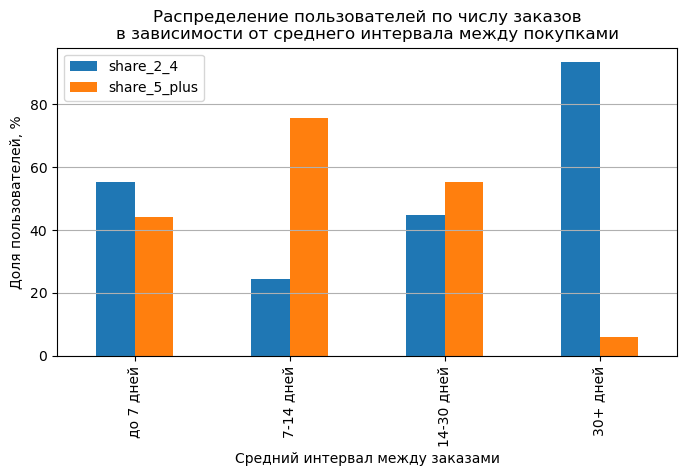

In [124]:
plt.figure(figsize=(8, 4))

days_return[
    ['share_2_4', 'share_5_plus']
].plot(
    kind='bar',
    figsize=(8, 4)
)

plt.title(
    'Распределение пользователей по числу заказов\nв зависимости от среднего интервала между покупками'
)
plt.xlabel('Средний интервал между заказами')
plt.ylabel('Доля пользователей, %')
plt.grid(axis='y')

plt.show()

**!!!** Если честно, мне не очень понятна задача: "Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа". Очевидно, рассматривая предложенные группы 2-4 заказа и 5+ заказов в определенных временных рамках в 5 месяцев, мы получим, что интервалы для пользователей с 5+ заказами будут меньше, чем интервалы между заказами для тех, кто сделал 2-4 заказа... Но попробуем сделать вывод для полученных результатов.

Анализ показал, что пользователи, совершившие 5 и более заказов, оформляют покупки заметно чаще: их средний интервал между заказами составляет около 10 дней, тогда как у пользователей с 2-4 заказами этот показатель превышает 21 день. Однако медианное значение для двух групп практически не отличается: 9 дней для пользователей с 2-4 заказами и 8 дней для пользователей с 5+ заказами. По графику расределения можно отметить, что пользователи с 2-4 заказами значительно чаще совершали повторные заказы с интервалом 1-2 дня, однако также значительно чаще, чем для пользователей с 5+ заказами, пользователи с 2-4 заказами совершали покупками с длинными перерывами (более 37.5 дней).

При сегментации пользователей по среднему интервалу между покупками выяснилось, что наибольшая доля пользователей с 5 и более заказами наблюдается в группах с интервалом 7-14 дней (75.63%) и 14-30 дней (55.16%). Напротив, среди пользователей, совершающих покупки в среднем реже одного раза в месяц, доля клиентов с 5 и более заказами составляет лишь 6%, тогда как 93.44% остаются в группе с 2-4 заказами.

Таким образом, можно сделать вывод, что более короткий интервал между покупками связан с более высоким уровнем удержания и большей вероятностью того, что пользователь станет активным клиентом платформы. Пользователи, регулярно совершающие покупки с интервалом до нескольких недель, чаще накапливают большое количество заказов, тогда как длительные перерывы между покупками являются признаком снижения вовлечённости и более низкой пользовательской активности.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

Порабаотаем с исходным количеством заказов `orders_count` в `user_profile_filtered`. Выделим для `phi_k` признаки профиля:

In [125]:
corr_df = user_profile_filtered[
    [
        'orders_count',
        'avg_revenue_rub',
        'avg_tickets',
        'avg_days_since_prev',
        'first_device',
        'first_region',
        'first_service',
        'first_event_type',
        'first_order_weekday'
    ]
]

Рассчитаем коэффициент корреляции `phi_k` (используем фишку для закраски, чтобы легче отследить минимальные и максимальные значения):

In [126]:
phik_corr = corr_df.phik_matrix(
    interval_cols=[
        'orders_count',
        'avg_revenue_rub',
        'avg_tickets',
        'avg_days_since_prev'
    ]
)

phik_corr.style.background_gradient(cmap='RdYlGn_r')

,orders_count,avg_revenue_rub,avg_tickets,avg_days_since_prev,first_device,first_region,first_service,first_event_type,first_order_weekday
orders_count,1.000000,0.219482,0.225904,0.284222,0.025945,0.113663,0.029112,0.027745,0.060831
avg_revenue_rub,0.219482,1.000000,0.458801,0.094216,0.076388,0.363157,0.380621,0.329006,0.016283
avg_tickets,0.225904,0.458801,1.000000,0.099038,0.055562,0.163874,0.066879,0.095617,0.003671
avg_days_since_prev,0.284222,0.094216,0.099038,1.000000,0.018280,0.081133,0.058040,0.049417,0.000000
first_device,0.025945,0.076388,0.055562,0.018280,1.000000,0.116370,0.083996,0.061771,0.073356
first_region,0.113663,0.363157,0.163874,0.081133,0.116370,1.000000,0.696751,0.509207,0.152721
first_service,0.029112,0.380621,0.066879,0.058040,0.083996,0.696751,1.000000,0.589297,0.063498
first_event_type,0.027745,0.329006,0.095617,0.049417,0.061771,0.509207,0.589297,1.000000,0.083437
first_order_weekday,0.060831,0.016283,0.003671,0.000000,0.073356,0.152721,0.063498,0.083437,1.000000


И построим тепловую карту для наглядности:

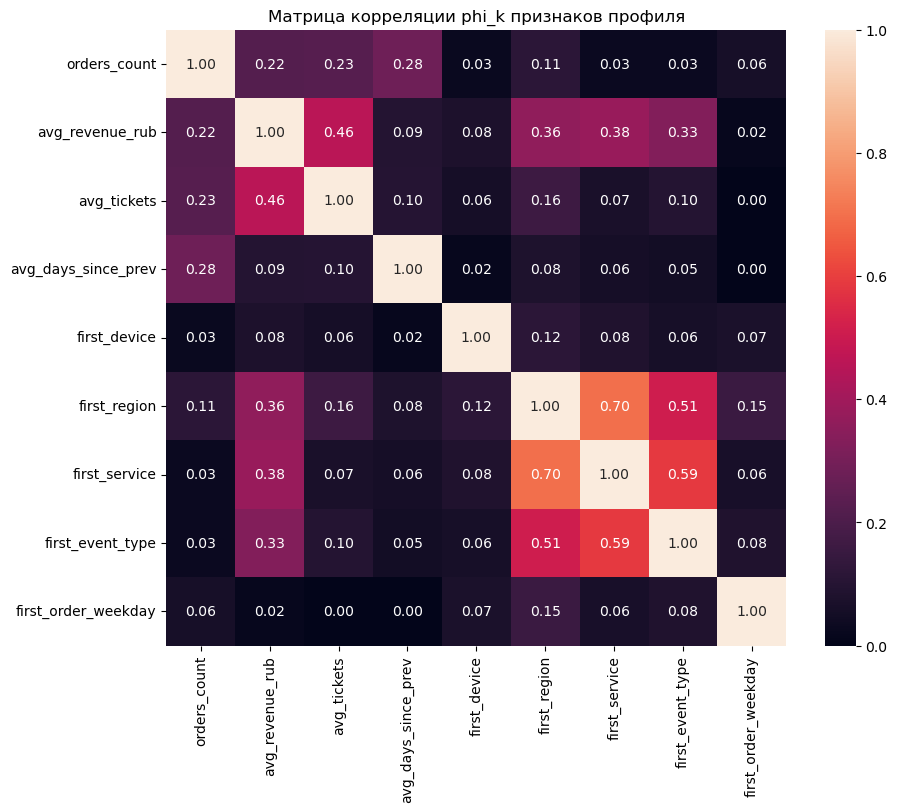

In [127]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    data=phik_corr,
    annot=True,
    fmt='.2f'
)

plt.title(
    'Матрица корреляции phi_k признаков профиля'
)

plt.show()

(Судя по результатам, корреляция близка к нулю только в некоторых случаях, поэтому опустим второй подпукт задания с сегментацией по числу заказов).

Коэффициент `phi_k` показал, что большинство признаков имеют слабую связь с количеством заказов пользователя (`orders_count`).

Наиболее сильная связь наблюдается между количеством заказов и средним временем между покупками (`avg_days_since_prev`) - коэффициент `phi_k` составил 0.28. Это соответствует слабой или близкой к умеренной связи и согласуется с предыдущими результатами исследования: пользователи, совершающие покупки чаще, обычно накапливают больше заказов.

Сопоставимую по силе связь показывают:
- среднее количество билетов в заказе (`avg_tickets`) - 0.23;
- средняя выручка с заказа (`avg_revenue_rub`) - 0.22.

Это позволяет предположить, что пользователи, покупающие больше билетов и оформляющие более крупные заказы, в среднем совершают больше покупок на платформе.

Среди категориальных признаков наиболее заметную связь с количеством заказов демонстрирует регион первого заказа (`first_region`) - 0.11. Однако эта связь существенно слабее, чем у количественных характеристик поведения пользователя.

Остальные признаки практически не связаны с количеством заказов:
- день недели первого заказа - 0.06;
- билетный оператор первого заказа - 0.03;
- тип первого мероприятия - 0.03;
- устройство первого заказа - 0.03.

Таким образом, наибольшую связь с количеством заказов показывают поведенческие признаки пользователя: средний интервал между покупками, среднее количество билетов в заказе и средняя выручка с заказа. Напротив, характеристики первого заказа (устройство, тип мероприятия, билетный оператор и день недели покупки) практически не позволяют объяснить различия в количестве заказов пользователей.

Следует учитывать, что признак `avg_days_since_prev` рассчитывается на основе истории заказов пользователя и фактически формируется уже после совершения нескольких покупок. Поэтому его высокая связь с количеством заказов не означает, что этот признак можно использовать для прогнозирования поведения новых пользователей сразу после первого заказа.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Общий вывод и рекомендации**

В ходе исследования были проанализированы данные сервиса Яндекс Афиша за период наблюдения с 01.06 по 31.10 в 2024 году. Исходный датасет содержал информацию о заказах пользователей, характеристиках мероприятий, билетных операторов и параметрах покупок.

На этапе подготовки данных выручка была приведена к единой валюте (российскому рублю) с использованием ежедневных курсов тенге. Были проверены пропуски и типы данных, оптимизированы категориальные признаки, а также удалены экстремальные выбросы по выручке (значения выше 99-го перцентиля). Дополнительно для анализа поведения пользователей были отфильтрованы пользователи с аномально большим числом заказов (выше 99-го перцентиля по количеству заказов за анализируемый период).

После очистки данных был построен профиль пользователя, включающий характеристики первого заказа, показатели покупательской активности и дугие признаки.

**Основные результаты анализа**

В выборке осталось 21638 пользователей. Поведение пользователей характеризуется неоднородностью: большинство пользователей совершают небольшое количество заказов, тогда как небольшая группа пользователей формирует значительную долю всей активности.

Доля пользователей, совершивших два и более заказа, составила около 62%, а доля пользователей с пятью и более заказами - около 29%, что говорит о достаточно высоком уровне удержания клиентов.

**Факторы первого заказа и возврат пользователей**

Пользователи распределены по сегментам неравномерно. Основными точками входа на платформу являются:
- `концерты` как первое мероприятие;
- `мобильные` устройства;
- несколько крупнейших регионов (`Каменевский регион` и `Североярская область`);
- ограниченное число крупных билетных операторов (`Билеты без проблем`, `Мой билет`, `Лови билет!`, `Билеты в руки`,  `Облачко`).

При анализе возвратов наиболее успешными точками входа оказались:
- `выставки` и `театр` среди типов мероприятий;
- отдельные регионы с высоким уровнем удержания (`Шанырский регион`, `Светополянский округ`, `Широковская область`);
- некоторые билетные операторы, обеспечивающие более высокий процент повторных заказов (`Край билетов` и `Дом культуры`).

При этом проверка гипотез показала, что пользователи, впервые купившие билеты на `концерты`, возвращаются чаще пользователей, начавших взаимодействие со `спортивных` мероприятий. А гипотеза о том, что в регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах, подтвердилась частично.

**Выручка и количество билетов**

Связь между средней выручкой и повторными покупками существует, однако она выражена умеренно.

Пользователи с повторными покупками имеют более высокую медианную выручку с заказа по сравнению с пользователями, совершившими только один заказ. При этом различия по средней выручке между группами пользователей с 2-4 и 5+ заказами невелики. Однако можно отметить, что пользователи с 5 и более заказами демонстрируют более стабильный уровень средней выручки, тогда как среди пользователей с 2-4 заказами чаще встречаются случаи очень высокой средней выручки с заказа.

Более заметная связь наблюдается для количества билетов в заказе. Максимальную долю повторных покупок показал сегмент пользователей, приобретающих в среднем от 2 до 3 билетов за заказ. Напротив, пользователи с 1-2 билетами или больше 3 билетов возвращаются реже.

**Временные характеристики**

День недели первой покупки практически не влияет на вероятность возврата пользователя. Различия между днями недели составляют лишь 1-2 процента и значительно уступают различиям между другими сегментами.

В то же время важным фактором удержания оказался интервал между покупками. Пользователи, совершающие покупки регулярно и с небольшими промежутками времени, значительно чаще переходят в категорию активных клиентов с большим количеством заказов. Длительные интервалы между покупками, наоборот, связаны с более низкой пользовательской активностью.

**Корреляционный анализ**

Корреляционный анализ показал, что наибольшую связь с количеством заказов имеют поведенческие характеристики пользователя:
- средний интервал между покупками;
- среднее количество билетов в заказе;
- средняя выручка с заказа.

Характеристики первого заказа (тип устройства, день недели, билетный оператор, тип мероприятия) демонстрируют лишь слабую связь с итоговым количеством заказов.

Важно отметить, что интервал между покупками является следствием уже сформировавшегося поведения пользователя и не может использоваться как ранний предиктор сразу после первого заказа.

**Рекомендации**

1. Сосредоточить усилия на сегменте пользователей, приобретающих 2-3 билета за заказ.

Этот сегмент демонстрирует наиболее высокий уровень удержания и может быть наиболее перспективным для программ лояльности и персонализированных предложений.

2. Развивать наиболее успешные точки входа.

Пользователи, впервые приобретающие билеты на `выставки` и `театральные постановки`, показывают повышенную вероятность возврата. Эти категории могут использоваться как эффективный канал привлечения лояльной аудитории.

3. Отдельно проанализировать причины низкого удержания пользователей с 1-2 билетами в заказе.

Это крупный сегмент пользователей, поэтому даже небольшое повышение их возвратности может существенно повлиять на общие показатели.

4. Разработать механики стимулирования повторной покупки в течение первого месяца после заказа.

Анализ показал, что увеличение интервала между покупками связано со снижением активности пользователей. Напоминания, персональные рекомендации и специальные предложения могут помочь сократить время до следующей покупки.

5. Использовать региональные различия при планировании маркетинговых активностей.

Некоторые регионы демонстрируют более высокий уровень удержания. Практики привлечения пользователей из таких регионов могут быть масштабированы на другие территории.

6. Не использовать день недели первой покупки как основной критерий сегментации пользователей.

Его влияние на удержание оказалось минимальным.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**

https://github.com/anthony-bogi/DS_Sprint9_Yandex_Afisha